# Чувствительность плотности к начальной точке просмотра

Проверяем, насколько выбор начальной точки greedy-подсчета неперекрывающихся ценовых движений влияет на оценку плотности.

Для каждой валюты, горизонта `1..120` минут и порогов `0.5%`, `1.0%`, `1.5%` считаем плотность при стартовых сдвигах `0..120` минут. Затем сравниваем разброс плотности по сдвигам с базовым расчетом при `start_offset=0`.

Отдельно считаем:
- весь доступный период;
- последний полный квартал в данных.

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import warnings

import pyarrow.parquet as pq

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import boto3
except ImportError:
    boto3 = None

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

try:
    from numba import njit
    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False
    njit = None

print(f"numba available: {NUMBA_AVAILABLE}")

numba available: True


In [3]:
S3_BUCKET = "binance-data-downloader"
ORIGINAL_S3_KEY = "minute_returns_dataset/features/minute_returns_1m_2020-02-01_2026-02-01.parquet"
XRP_REPAIRED_S3_KEY = "minute_returns_dataset/features/minute_returns_1m_2020-02-01_2026-02-01_xrp_repaired.parquet"

USE_XRP_REPAIRED_DATASET = True
S3_KEY = XRP_REPAIRED_S3_KEY if USE_XRP_REPAIRED_DATASET else ORIGINAL_S3_KEY

CACHE_DIR = Path("cache") if Path.cwd().name == "analysis" else Path("analysis/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_ORIGINAL_PARQUET = CACHE_DIR / Path(ORIGINAL_S3_KEY).name
LOCAL_XRP_REPAIRED_PARQUET = CACHE_DIR / Path(XRP_REPAIRED_S3_KEY).name
LOCAL_PARQUET = LOCAL_XRP_REPAIRED_PARQUET if USE_XRP_REPAIRED_DATASET else LOCAL_ORIGINAL_PARQUET

OUTPUT_DIR = CACHE_DIR / "start_offset_sensitivity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZONS = list(range(1, 121))
THRESHOLDS = [0.005, 0.010, 0.015]
THRESHOLD_LABELS = [round(t * 100, 1) for t in THRESHOLDS]
START_OFFSETS = list(range(0, 121))

SELECTED_SYMBOLS: list[str] | None = None
TIMESTAMP_CANDIDATES = ["timestamp", "open_time", "datetime", "date"]

FORCE_RECOMPUTE = False
LAST_QUARTER_MODE = "last_full"  # "last_full" ??? "last_calendar"

print("local parquet:", LOCAL_PARQUET)
print("threshold_pct:", THRESHOLD_LABELS)
print("horizons:", f"{min(HORIZONS)}..{max(HORIZONS)}")
print("start_offsets:", f"{min(START_OFFSETS)}..{max(START_OFFSETS)}")
print("output dir:", OUTPUT_DIR)

local parquet: cache\minute_returns_1m_2020-02-01_2026-02-01_xrp_repaired.parquet
threshold_pct: [0.5, 1.0, 1.5]
horizons: 1..120
start_offsets: 0..120
output dir: cache\start_offset_sensitivity


In [4]:
def ensure_local_parquet(bucket: str = S3_BUCKET, key: str = S3_KEY, local_path: Path = LOCAL_PARQUET) -> Path:
    if local_path.exists():
        print(f"Using cached parquet: {local_path}")
        return local_path

    if boto3 is None:
        raise ImportError("boto3 is not installed and local parquet is missing")

    print(f"Downloading s3://{bucket}/{key} -> {local_path}")
    local_path.parent.mkdir(parents=True, exist_ok=True)
    boto3.client("s3").download_file(bucket, key, str(local_path))
    return local_path


def detect_timestamp_column(columns: list[str]) -> str:
    for candidate in TIMESTAMP_CANDIDATES:
        if candidate in columns:
            return candidate
    raise ValueError(f"No timestamp column found. Available columns: {columns[:20]}")


def symbol_from_return_column(column: str) -> str:
    return column.removesuffix("_return")


def return_column_for_symbol(symbol: str) -> str:
    return symbol if symbol.endswith("_return") else f"{symbol}_return"


local_parquet = ensure_local_parquet()
all_columns = pq.ParquetFile(local_parquet).schema_arrow.names
timestamp_column = detect_timestamp_column(all_columns)
return_columns = [c for c in all_columns if c != timestamp_column and c.endswith("_return")]

if SELECTED_SYMBOLS is None:
    selected_return_columns = return_columns
else:
    selected_return_columns = [return_column_for_symbol(s) for s in SELECTED_SYMBOLS]
    missing = sorted(set(selected_return_columns) - set(return_columns))
    if missing:
        raise ValueError(f"Missing selected return columns: {missing}")

returns = pd.read_parquet(local_parquet, columns=[timestamp_column, *selected_return_columns])
returns[timestamp_column] = pd.to_datetime(returns[timestamp_column], utc=True)
returns = returns.sort_values(timestamp_column).reset_index(drop=True)

print(f"Rows: {len(returns):,}")
print(f"Range: {returns[timestamp_column].min()} .. {returns[timestamp_column].max()}")
print(f"Symbols: {len(selected_return_columns)}")
display(pd.DataFrame({"return_column": selected_return_columns, "symbol": [symbol_from_return_column(c) for c in selected_return_columns]}))

Using cached parquet: cache\minute_returns_1m_2020-02-01_2026-02-01_xrp_repaired.parquet
Rows: 3,157,257
Range: 2020-02-01 00:02:00+00:00 .. 2026-02-01 23:59:00+00:00
Symbols: 9


,return_column,symbol
0,BTCUSDT_return,BTCUSDT
1,ETHUSDT_return,ETHUSDT
2,BNBUSDT_return,BNBUSDT
3,DOGEUSDT_return,DOGEUSDT
4,XRPUSDT_return,XRPUSDT
5,SOLUSDT_return,SOLUSDT
6,TRXUSDT_return,TRXUSDT
7,ADAUSDT_return,ADAUSDT
8,BCHUSDT_return,BCHUSDT


In [5]:
def forward_compound_return(minute_returns: pd.Series, horizon: int) -> pd.Series:
    values = minute_returns.astype("float64").replace([np.inf, -np.inf], np.nan)
    log_values = np.log1p(values)
    rolled = log_values.shift(-1).rolling(window=horizon, min_periods=horizon).sum().shift(-(horizon - 1))
    return np.expm1(rolled)


if NUMBA_AVAILABLE:
    @njit
    def count_non_overlapping_events_by_offsets_numba(starts: np.ndarray, horizon: int, offsets: np.ndarray) -> np.ndarray:
        counts = np.zeros(len(offsets), dtype=np.int64)
        for k in range(len(offsets)):
            offset = offsets[k]
            count = 0
            blocked_until = offset
            for idx in range(len(starts)):
                start = starts[idx]
                if start < offset:
                    continue
                if start >= blocked_until:
                    count += 1
                    blocked_until = start + horizon
            counts[k] = count
        return counts
else:
    def count_non_overlapping_events_by_offsets_numba(starts: np.ndarray, horizon: int, offsets: np.ndarray) -> np.ndarray:
        counts = np.zeros(len(offsets), dtype=np.int64)
        for k, offset in enumerate(offsets):
            count = 0
            blocked_until = int(offset)
            for start in starts:
                start = int(start)
                if start < offset:
                    continue
                if start >= blocked_until:
                    count += 1
                    blocked_until = start + horizon
            counts[k] = count
        return counts


def count_finite_observations_by_offsets(finite: np.ndarray, offsets: np.ndarray) -> np.ndarray:
    finite_int = finite.astype(np.int64)
    suffix_counts = np.cumsum(finite_int[::-1])[::-1]
    out = np.zeros(len(offsets), dtype=np.int64)
    n = len(finite)
    for k, offset in enumerate(offsets):
        out[k] = int(suffix_counts[offset]) if offset < n else 0
    return out


def iter_with_progress(items, desc: str):
    if tqdm is None:
        return items
    return tqdm(items, desc=desc)

In [6]:
def shifted_density_curve_for_series(
    minute_returns: pd.Series,
    symbol: str,
    horizons: list[int] = HORIZONS,
    thresholds: list[float] = THRESHOLDS,
    start_offsets: list[int] = START_OFFSETS,
) -> pd.DataFrame:
    rows = []
    offset_array = np.asarray(start_offsets, dtype=np.int64)

    for horizon in horizons:
        future = forward_compound_return(minute_returns, horizon)
        abs_future = future.abs().to_numpy(dtype=np.float64)
        finite = np.isfinite(abs_future)
        possible_by_offset = count_finite_observations_by_offsets(finite, offset_array)
        days_by_offset = possible_by_offset / 1440.0

        for threshold in thresholds:
            starts = np.flatnonzero(finite & (abs_future >= threshold)).astype(np.int64)
            counts = count_non_overlapping_events_by_offsets_numba(starts, int(horizon), offset_array)
            density = np.divide(
                counts,
                days_by_offset,
                out=np.full_like(days_by_offset, np.nan, dtype=np.float64),
                where=days_by_offset > 0,
            )

            for offset, possible, days, events, density_value in zip(
                offset_array,
                possible_by_offset,
                days_by_offset,
                counts,
                density,
            ):
                rows.append(
                    {
                        "symbol": symbol,
                        "threshold": float(threshold),
                        "threshold_pct": round(float(threshold) * 100, 1),
                        "horizon": int(horizon),
                        "start_offset": int(offset),
                        "independent_events": int(events),
                        "possible_observations": int(possible),
                        "days": float(days),
                        "density_per_day": float(density_value) if np.isfinite(density_value) else np.nan,
                    }
                )

    return pd.DataFrame(rows)


def build_shifted_density_curves(
    frame: pd.DataFrame,
    return_cols: list[str],
    scope_name: str,
) -> pd.DataFrame:
    parts = []
    for col in iter_with_progress(return_cols, desc=f"{scope_name}: symbols"):
        symbol = symbol_from_return_column(col)
        print(f"{scope_name}: computing {symbol}")
        part = shifted_density_curve_for_series(frame[col], symbol=symbol)
        part["scope"] = scope_name
        parts.append(part)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

In [7]:
def select_last_quarter_frame(
    frame: pd.DataFrame,
    timestamp_col: str = timestamp_column,
    mode: str = LAST_QUARTER_MODE,
) -> tuple[pd.DataFrame, str, pd.Timestamp, pd.Timestamp]:
    tmp = frame.copy()
    tmp["quarter"] = tmp[timestamp_col].dt.to_period("Q")

    quarter_sizes = (
        tmp.groupby("quarter")
        .agg(
            start=(timestamp_col, "min"),
            end=(timestamp_col, "max"),
            rows=(timestamp_col, "size"),
        )
        .reset_index()
    )

    if mode == "last_calendar":
        chosen = quarter_sizes.iloc[-1]
    elif mode == "last_full":
        full_quarters = []
        for _, row in quarter_sizes.iterrows():
            quarter = row["quarter"]
            q_start = quarter.start_time.tz_localize("UTC")
            q_end = quarter.end_time.tz_localize("UTC")
            has_start = row["start"] <= q_start + pd.Timedelta(minutes=5)
            has_end = row["end"] >= q_end - pd.Timedelta(minutes=5)
            if has_start and has_end:
                full_quarters.append(row)
        if not full_quarters:
            warnings.warn("No full quarter found; falling back to last calendar quarter")
            chosen = quarter_sizes.iloc[-1]
        else:
            chosen = pd.DataFrame(full_quarters).iloc[-1]
    else:
        raise ValueError("mode must be 'last_full' or 'last_calendar'")

    chosen_quarter = chosen["quarter"]
    label = f"{chosen_quarter.year}-Q{chosen_quarter.quarter}"
    out = tmp.loc[tmp["quarter"].eq(chosen_quarter)].drop(columns=["quarter"]).reset_index(drop=True)
    return out, label, chosen["start"], chosen["end"]


last_quarter_returns, last_quarter_label, last_quarter_start, last_quarter_end = select_last_quarter_frame(returns)

print("Last quarter mode:", LAST_QUARTER_MODE)
print("Selected quarter:", last_quarter_label)
print("Range:", last_quarter_start, "..", last_quarter_end)
print("Rows:", f"{len(last_quarter_returns):,}")

Last quarter mode: last_full
Selected quarter: 2025-Q4
Range: 2025-10-01 00:00:00+00:00 .. 2025-12-31 23:59:00+00:00
Rows: 132,480


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_9596\1374705990.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tmp["quarter"] = tmp[timestamp_col].dt.to_period("Q")


In [8]:
def parquet_path_for_scope(scope_name: str) -> Path:
    return OUTPUT_DIR / f"density_by_start_offset_{scope_name}.parquet"


def load_or_compute_scope(scope_name: str, frame: pd.DataFrame) -> pd.DataFrame:
    path = parquet_path_for_scope(scope_name)
    if path.exists() and not FORCE_RECOMPUTE:
        print(f"Loading cached {scope_name}: {path}")
        return pd.read_parquet(path)

    curves = build_shifted_density_curves(frame, selected_return_columns, scope_name=scope_name)
    curves.to_parquet(path, index=False)
    print(f"Saved {scope_name}: {path}")
    return curves


full_offset_density = load_or_compute_scope("full_period", returns)
last_quarter_offset_density = load_or_compute_scope(f"last_quarter_{last_quarter_label}", last_quarter_returns)

print("full rows:", f"{len(full_offset_density):,}")
print("last quarter rows:", f"{len(last_quarter_offset_density):,}")
display(full_offset_density.head())

Loading cached full_period: cache\start_offset_sensitivity\density_by_start_offset_full_period.parquet
Loading cached last_quarter_2025-Q4: cache\start_offset_sensitivity\density_by_start_offset_last_quarter_2025-Q4.parquet
full rows: 392,040
last quarter rows: 392,040


,symbol,threshold,threshold_pct,horizon,start_offset,independent_events,possible_observations,days,density_per_day,scope
0,BTCUSDT,0.005,0.5,1,0,10135,3157026,2192.379167,4.622832,full_period
1,BTCUSDT,0.005,0.5,1,1,10135,3157025,2192.378472,4.622833,full_period
2,BTCUSDT,0.005,0.5,1,2,10135,3157024,2192.377778,4.622835,full_period
3,BTCUSDT,0.005,0.5,1,3,10135,3157023,2192.377083,4.622836,full_period
4,BTCUSDT,0.005,0.5,1,4,10135,3157022,2192.376389,4.622838,full_period


In [9]:
def summarize_offset_sensitivity(curves: pd.DataFrame) -> pd.DataFrame:
    keys = ["scope", "symbol", "threshold", "threshold_pct", "horizon"]
    baseline = (
        curves.loc[curves["start_offset"].eq(0), keys + ["density_per_day", "independent_events"]]
        .rename(columns={"density_per_day": "baseline_density_per_day", "independent_events": "baseline_events"})
    )

    summary = (
        curves.groupby(keys, dropna=False)
        .agg(
            offsets=("start_offset", "nunique"),
            mean_density_per_day=("density_per_day", "mean"),
            std_density_per_day=("density_per_day", "std"),
            min_density_per_day=("density_per_day", "min"),
            max_density_per_day=("density_per_day", "max"),
            q05_density_per_day=("density_per_day", lambda x: x.quantile(0.05)),
            q50_density_per_day=("density_per_day", "median"),
            q95_density_per_day=("density_per_day", lambda x: x.quantile(0.95)),
            min_events=("independent_events", "min"),
            max_events=("independent_events", "max"),
        )
        .reset_index()
        .merge(baseline, on=keys, how="left")
    )

    summary["density_range_abs"] = summary["max_density_per_day"] - summary["min_density_per_day"]
    summary["density_iqr90_abs"] = summary["q95_density_per_day"] - summary["q05_density_per_day"]
    summary["density_std_pct_of_baseline"] = summary["std_density_per_day"] / summary["baseline_density_per_day"] * 100
    summary["density_range_pct_of_baseline"] = summary["density_range_abs"] / summary["baseline_density_per_day"] * 100
    summary["density_iqr90_pct_of_baseline"] = summary["density_iqr90_abs"] / summary["baseline_density_per_day"] * 100
    summary["event_range"] = summary["max_events"] - summary["min_events"]

    return summary.replace([np.inf, -np.inf], np.nan)


def summarize_best_horizon_by_offset(curves: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    idx = curves.groupby(["scope", "symbol", "threshold", "threshold_pct", "start_offset"])["density_per_day"].idxmax()
    best_by_offset = (
        curves.loc[idx, ["scope", "symbol", "threshold", "threshold_pct", "start_offset", "horizon", "density_per_day", "independent_events"]]
        .rename(columns={"horizon": "best_horizon", "density_per_day": "best_density_per_day"})
        .sort_values(["scope", "symbol", "threshold_pct", "start_offset"])
        .reset_index(drop=True)
    )

    best_summary = (
        best_by_offset.groupby(["scope", "symbol", "threshold", "threshold_pct"], dropna=False)
        .agg(
            offsets=("start_offset", "nunique"),
            baseline_best_horizon=("best_horizon", lambda x: x.iloc[0]),
            mean_best_horizon=("best_horizon", "mean"),
            std_best_horizon=("best_horizon", "std"),
            min_best_horizon=("best_horizon", "min"),
            q25_best_horizon=("best_horizon", lambda x: x.quantile(0.25)),
            median_best_horizon=("best_horizon", "median"),
            q75_best_horizon=("best_horizon", lambda x: x.quantile(0.75)),
            max_best_horizon=("best_horizon", "max"),
            unique_best_horizons=("best_horizon", "nunique"),
            mean_best_density_per_day=("best_density_per_day", "mean"),
            std_best_density_per_day=("best_density_per_day", "std"),
        )
        .reset_index()
    )
    best_summary["best_horizon_range"] = best_summary["max_best_horizon"] - best_summary["min_best_horizon"]

    return best_by_offset, best_summary


all_offset_density = pd.concat([full_offset_density, last_quarter_offset_density], ignore_index=True)
offset_sensitivity_summary = summarize_offset_sensitivity(all_offset_density)
best_horizon_by_offset, best_horizon_offset_summary = summarize_best_horizon_by_offset(all_offset_density)

summary_path = OUTPUT_DIR / "offset_sensitivity_summary.parquet"
best_by_offset_path = OUTPUT_DIR / "best_horizon_by_start_offset.parquet"
best_summary_path = OUTPUT_DIR / "best_horizon_start_offset_summary.parquet"

offset_sensitivity_summary.to_parquet(summary_path, index=False)
best_horizon_by_offset.to_parquet(best_by_offset_path, index=False)
best_horizon_offset_summary.to_parquet(best_summary_path, index=False)

print("Saved summaries:")
print(summary_path)
print(best_by_offset_path)
print(best_summary_path)

display(offset_sensitivity_summary.head())
display(best_horizon_offset_summary.head())

Saved summaries:
cache\start_offset_sensitivity\offset_sensitivity_summary.parquet
cache\start_offset_sensitivity\best_horizon_by_start_offset.parquet
cache\start_offset_sensitivity\best_horizon_start_offset_summary.parquet


,scope,symbol,threshold,threshold_pct,horizon,offsets,mean_density_per_day,std_density_per_day,min_density_per_day,max_density_per_day,q05_density_per_day,q50_density_per_day,q95_density_per_day,min_events,max_events,baseline_density_per_day,baseline_events,density_range_abs,density_iqr90_abs,density_std_pct_of_baseline,density_range_pct_of_baseline,density_iqr90_pct_of_baseline,event_range
0,full_period,ADAUSDT,0.005,0.5,1,121,18.072987,0.000201,18.072644,18.073331,18.072678,18.072987,18.073296,39622,39622,18.072644,39622,0.000687,0.000618,0.001111,0.003801,0.003421,0
1,full_period,ADAUSDT,0.005,0.5,2,121,32.044301,0.000196,32.043933,32.044695,32.043994,32.044299,32.044634,70246,70247,32.043933,70247,0.000762,0.000640,0.000611,0.002378,0.001998,1
2,full_period,ADAUSDT,0.005,0.5,3,121,39.116242,0.000374,39.115551,39.116865,39.115626,39.116295,39.116791,85742,85743,39.115551,85743,0.001314,0.001165,0.000956,0.003358,0.002978,1
3,full_period,ADAUSDT,0.005,0.5,4,121,42.822064,0.000406,42.821342,42.822767,42.821424,42.822075,42.822686,93858,93860,42.821717,93860,0.001425,0.001262,0.000948,0.003327,0.002947,2
4,full_period,ADAUSDT,0.005,0.5,5,121,44.941233,0.000240,44.940728,44.941725,44.940814,44.941241,44.941639,98495,98498,44.941099,98498,0.000996,0.000825,0.000533,0.002217,0.001836,3


,scope,symbol,threshold,threshold_pct,offsets,baseline_best_horizon,mean_best_horizon,std_best_horizon,min_best_horizon,q25_best_horizon,median_best_horizon,q75_best_horizon,max_best_horizon,unique_best_horizons,mean_best_density_per_day,std_best_density_per_day,best_horizon_range
0,full_period,ADAUSDT,0.005,0.5,121,7,7.0,0.0,7,7.0,7.0,7.0,7,1,46.676567,0.000222,0
1,full_period,ADAUSDT,0.010,1.0,121,22,22.0,0.0,22,22.0,22.0,22.0,22,1,14.181996,0.000123,0
2,full_period,ADAUSDT,0.015,1.5,121,41,41.0,0.0,41,41.0,41.0,41.0,41,1,6.828874,0.000265,0
3,full_period,BCHUSDT,0.005,0.5,121,8,8.0,0.0,8,8.0,8.0,8.0,8,1,37.406350,0.000232,0
4,full_period,BCHUSDT,0.010,1.0,121,22,22.0,0.0,22,22.0,22.0,22.0,22,1,11.389804,0.000170,0


## Альтернативный порядок обработки: reverse greedy

Проверяем вторую часть замечания рецензента: зависимость от порядка обработки наблюдений.

Базовый алгоритм просматривает кандидаты слева направо по времени. Здесь считаем альтернативный вариант: кандидаты обрабатываются справа налево, при выборе события назад исключаются пересекающиеся интервалы. Дальше сравниваем плотность и оптимальный горизонт между `forward` и `reverse` для тех же стартовых сдвигов.

In [10]:
if NUMBA_AVAILABLE:
    @njit
    def count_non_overlapping_events_by_offsets_reverse_numba(
        starts: np.ndarray,
        horizon: int,
        offsets: np.ndarray,
        n_positions: int,
    ) -> np.ndarray:
        counts = np.zeros(len(offsets), dtype=np.int64)
        for k in range(len(offsets)):
            offset = offsets[k]
            count = 0
            blocked_from = n_positions
            for idx in range(len(starts) - 1, -1, -1):
                start = starts[idx]
                if start < offset:
                    break
                end = start + horizon
                if end <= blocked_from:
                    count += 1
                    blocked_from = start
            counts[k] = count
        return counts
else:
    def count_non_overlapping_events_by_offsets_reverse_numba(
        starts: np.ndarray,
        horizon: int,
        offsets: np.ndarray,
        n_positions: int,
    ) -> np.ndarray:
        counts = np.zeros(len(offsets), dtype=np.int64)
        for k, offset in enumerate(offsets):
            count = 0
            blocked_from = n_positions
            for start in starts[::-1]:
                start = int(start)
                if start < offset:
                    break
                end = start + horizon
                if end <= blocked_from:
                    count += 1
                    blocked_from = start
            counts[k] = count
        return counts


def reverse_shifted_density_curve_for_series(
    minute_returns: pd.Series,
    symbol: str,
    horizons: list[int] = HORIZONS,
    thresholds: list[float] = THRESHOLDS,
    start_offsets: list[int] = START_OFFSETS,
) -> pd.DataFrame:
    rows = []
    offset_array = np.asarray(start_offsets, dtype=np.int64)

    for horizon in horizons:
        future = forward_compound_return(minute_returns, horizon)
        abs_future = future.abs().to_numpy(dtype=np.float64)
        finite = np.isfinite(abs_future)
        possible_by_offset = count_finite_observations_by_offsets(finite, offset_array)
        days_by_offset = possible_by_offset / 1440.0
        n_positions = len(abs_future)

        for threshold in thresholds:
            starts = np.flatnonzero(finite & (abs_future >= threshold)).astype(np.int64)
            counts = count_non_overlapping_events_by_offsets_reverse_numba(
                starts,
                int(horizon),
                offset_array,
                int(n_positions),
            )
            density = np.divide(
                counts,
                days_by_offset,
                out=np.full_like(days_by_offset, np.nan, dtype=np.float64),
                where=days_by_offset > 0,
            )

            for offset, possible, days, events, density_value in zip(
                offset_array,
                possible_by_offset,
                days_by_offset,
                counts,
                density,
            ):
                rows.append(
                    {
                        "symbol": symbol,
                        "threshold": float(threshold),
                        "threshold_pct": round(float(threshold) * 100, 1),
                        "horizon": int(horizon),
                        "start_offset": int(offset),
                        "scan_order": "reverse",
                        "independent_events": int(events),
                        "possible_observations": int(possible),
                        "days": float(days),
                        "density_per_day": float(density_value) if np.isfinite(density_value) else np.nan,
                    }
                )

    return pd.DataFrame(rows)


def build_reverse_shifted_density_curves(
    frame: pd.DataFrame,
    return_cols: list[str],
    scope_name: str,
) -> pd.DataFrame:
    parts = []
    for col in iter_with_progress(return_cols, desc=f"{scope_name}: reverse symbols"):
        symbol = symbol_from_return_column(col)
        print(f"{scope_name}: reverse computing {symbol}")
        part = reverse_shifted_density_curve_for_series(frame[col], symbol=symbol)
        part["scope"] = scope_name
        parts.append(part)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def reverse_parquet_path_for_scope(scope_name: str) -> Path:
    return OUTPUT_DIR / f"density_by_start_offset_reverse_{scope_name}.parquet"


def load_or_compute_reverse_scope(scope_name: str, frame: pd.DataFrame) -> pd.DataFrame:
    path = reverse_parquet_path_for_scope(scope_name)
    if path.exists() and not FORCE_RECOMPUTE:
        print(f"Loading cached reverse {scope_name}: {path}")
        return pd.read_parquet(path)

    curves = build_reverse_shifted_density_curves(frame, selected_return_columns, scope_name=scope_name)
    curves.to_parquet(path, index=False)
    print(f"Saved reverse {scope_name}: {path}")
    return curves


forward_offset_density_for_order = all_offset_density.copy()
forward_offset_density_for_order["scan_order"] = "forward"

reverse_full_offset_density = load_or_compute_reverse_scope("full_period", returns)
reverse_last_quarter_offset_density = load_or_compute_reverse_scope(f"last_quarter_{last_quarter_label}", last_quarter_returns)
reverse_offset_density = pd.concat([reverse_full_offset_density, reverse_last_quarter_offset_density], ignore_index=True)

order_offset_density = pd.concat(
    [forward_offset_density_for_order, reverse_offset_density],
    ignore_index=True,
)

order_offset_density_path = OUTPUT_DIR / "density_by_start_offset_forward_reverse.parquet"
order_offset_density.to_parquet(order_offset_density_path, index=False)
print(order_offset_density_path)
print("forward rows:", f"{len(forward_offset_density_for_order):,}")
print("reverse rows:", f"{len(reverse_offset_density):,}")

full_period: reverse symbols:   0%|          | 0/9 [00:00<?, ?it/s]

full_period: reverse computing BTCUSDT


full_period: reverse symbols:  11%|█         | 1/9 [00:27<03:36, 27.02s/it]

full_period: reverse computing ETHUSDT


full_period: reverse symbols:  22%|██▏       | 2/9 [00:59<03:30, 30.11s/it]

...

last_quarter_2025-Q4: reverse computing ADAUSDT


last_quarter_2025-Q4: reverse symbols:  89%|████████▉ | 8/9 [00:12<00:01,  1.55s/it]

last_quarter_2025-Q4: reverse computing BCHUSDT


last_quarter_2025-Q4: reverse symbols: 100%|██████████| 9/9 [00:13<00:00,  1.55s/it]


Saved reverse last_quarter_2025-Q4: cache\start_offset_sensitivity\density_by_start_offset_reverse_last_quarter_2025-Q4.parquet
cache\start_offset_sensitivity\density_by_start_offset_forward_reverse.parquet
forward rows: 784,080
reverse rows: 784,080


In [11]:
def compare_forward_reverse_density(order_curves: pd.DataFrame) -> pd.DataFrame:
    keys = ["scope", "symbol", "threshold", "threshold_pct", "horizon", "start_offset"]
    wide = (
        order_curves.pivot_table(
            index=keys,
            columns="scan_order",
            values=["density_per_day", "independent_events"],
            aggfunc="first",
        )
        .reset_index()
    )
    wide.columns = ["_".join([str(x) for x in col if x != ""]).strip("_") if isinstance(col, tuple) else col for col in wide.columns]

    wide["density_diff_reverse_minus_forward"] = wide["density_per_day_reverse"] - wide["density_per_day_forward"]
    wide["density_abs_diff"] = wide["density_diff_reverse_minus_forward"].abs()
    wide["density_abs_diff_pct_of_forward"] = wide["density_abs_diff"] / wide["density_per_day_forward"] * 100
    wide["events_diff_reverse_minus_forward"] = wide["independent_events_reverse"] - wide["independent_events_forward"]
    wide["events_abs_diff"] = wide["events_diff_reverse_minus_forward"].abs()

    return wide.replace([np.inf, -np.inf], np.nan)


def summarize_forward_reverse_difference(diff: pd.DataFrame) -> pd.DataFrame:
    keys = ["scope", "symbol", "threshold", "threshold_pct", "horizon"]
    return (
        diff.groupby(keys, dropna=False)
        .agg(
            offsets=("start_offset", "nunique"),
            mean_abs_density_diff=("density_abs_diff", "mean"),
            max_abs_density_diff=("density_abs_diff", "max"),
            q95_abs_density_diff=("density_abs_diff", lambda x: x.quantile(0.95)),
            mean_abs_density_diff_pct_of_forward=("density_abs_diff_pct_of_forward", "mean"),
            max_abs_density_diff_pct_of_forward=("density_abs_diff_pct_of_forward", "max"),
            q95_abs_density_diff_pct_of_forward=("density_abs_diff_pct_of_forward", lambda x: x.quantile(0.95)),
            mean_abs_events_diff=("events_abs_diff", "mean"),
            max_abs_events_diff=("events_abs_diff", "max"),
        )
        .reset_index()
    )


forward_reverse_density_diff = compare_forward_reverse_density(order_offset_density)
forward_reverse_density_diff_summary = summarize_forward_reverse_difference(forward_reverse_density_diff)

forward_reverse_density_diff_path = OUTPUT_DIR / "forward_reverse_density_diff_by_offset.parquet"
forward_reverse_density_diff_summary_path = OUTPUT_DIR / "forward_reverse_density_diff_summary.parquet"
forward_reverse_density_diff.to_parquet(forward_reverse_density_diff_path, index=False)
forward_reverse_density_diff_summary.to_parquet(forward_reverse_density_diff_summary_path, index=False)

print(forward_reverse_density_diff_path)
print(forward_reverse_density_diff_summary_path)

display(
    forward_reverse_density_diff_summary.sort_values("max_abs_density_diff_pct_of_forward", ascending=False)
    .head(30)
)

cache\start_offset_sensitivity\forward_reverse_density_diff_by_offset.parquet
cache\start_offset_sensitivity\forward_reverse_density_diff_summary.parquet


,scope,symbol,threshold,threshold_pct,horizon,offsets,mean_abs_density_diff,max_abs_density_diff,q95_abs_density_diff,mean_abs_density_diff_pct_of_forward,max_abs_density_diff_pct_of_forward,q95_abs_density_diff_pct_of_forward,mean_abs_events_diff,max_abs_events_diff
0,full_period,ADAUSDT,0.005,0.5,1,121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,full_period,ADAUSDT,0.005,0.5,2,121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,full_period,ADAUSDT,0.005,0.5,3,121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,full_period,ADAUSDT,0.005,0.5,4,121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,full_period,ADAUSDT,0.005,0.5,5,121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,full_period,ADAUSDT,0.005,0.5,6,121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,full_period,ADAUSDT,0.005,0.5,7,121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
7,full_period,ADAUSDT,0.005,0.5,8,121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
8,full_period,ADAUSDT,0.005,0.5,9,121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
9,full_period,ADAUSDT,0.005,0.5,10,121,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [12]:
def summarize_best_horizon_by_offset_and_order(order_curves: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    idx = order_curves.groupby(
        ["scope", "scan_order", "symbol", "threshold", "threshold_pct", "start_offset"]
    )["density_per_day"].idxmax()

    best_by_offset_order = (
        order_curves.loc[
            idx,
            ["scope", "scan_order", "symbol", "threshold", "threshold_pct", "start_offset", "horizon", "density_per_day", "independent_events"],
        ]
        .rename(columns={"horizon": "best_horizon", "density_per_day": "best_density_per_day"})
        .sort_values(["scope", "symbol", "threshold_pct", "start_offset", "scan_order"])
        .reset_index(drop=True)
    )

    keys = ["scope", "symbol", "threshold", "threshold_pct", "start_offset"]
    wide = (
        best_by_offset_order.pivot_table(
            index=keys,
            columns="scan_order",
            values=["best_horizon", "best_density_per_day"],
            aggfunc="first",
        )
        .reset_index()
    )
    wide.columns = ["_".join([str(x) for x in col if x != ""]).strip("_") if isinstance(col, tuple) else col for col in wide.columns]
    wide["best_horizon_diff_reverse_minus_forward"] = wide["best_horizon_reverse"] - wide["best_horizon_forward"]
    wide["best_horizon_abs_diff"] = wide["best_horizon_diff_reverse_minus_forward"].abs()
    wide["best_density_diff_reverse_minus_forward"] = wide["best_density_per_day_reverse"] - wide["best_density_per_day_forward"]
    wide["best_density_abs_diff_pct_of_forward"] = wide["best_density_diff_reverse_minus_forward"].abs() / wide["best_density_per_day_forward"] * 100

    summary = (
        wide.groupby(["scope", "symbol", "threshold", "threshold_pct"], dropna=False)
        .agg(
            offsets=("start_offset", "nunique"),
            mean_abs_best_horizon_diff=("best_horizon_abs_diff", "mean"),
            max_abs_best_horizon_diff=("best_horizon_abs_diff", "max"),
            share_same_best_horizon=("best_horizon_abs_diff", lambda x: (x == 0).mean()),
            mean_best_density_abs_diff_pct_of_forward=("best_density_abs_diff_pct_of_forward", "mean"),
            max_best_density_abs_diff_pct_of_forward=("best_density_abs_diff_pct_of_forward", "max"),
        )
        .reset_index()
        .replace([np.inf, -np.inf], np.nan)
    )

    return wide, summary


forward_reverse_best_horizon_diff, forward_reverse_best_horizon_summary = summarize_best_horizon_by_offset_and_order(order_offset_density)

best_horizon_diff_path = OUTPUT_DIR / "forward_reverse_best_horizon_diff_by_offset.parquet"
best_horizon_summary_path = OUTPUT_DIR / "forward_reverse_best_horizon_summary.parquet"
forward_reverse_best_horizon_diff.to_parquet(best_horizon_diff_path, index=False)
forward_reverse_best_horizon_summary.to_parquet(best_horizon_summary_path, index=False)

print(best_horizon_diff_path)
print(best_horizon_summary_path)

display(
    forward_reverse_best_horizon_summary.sort_values("max_abs_best_horizon_diff", ascending=False)
    .head(30)
)

cache\start_offset_sensitivity\forward_reverse_best_horizon_diff_by_offset.parquet
cache\start_offset_sensitivity\forward_reverse_best_horizon_summary.parquet


,scope,symbol,threshold,threshold_pct,offsets,mean_abs_best_horizon_diff,max_abs_best_horizon_diff,share_same_best_horizon,mean_best_density_abs_diff_pct_of_forward,max_best_density_abs_diff_pct_of_forward
0,full_period,ADAUSDT,0.005,0.5,121,0.0,0,1.0,0.0,0.0
1,full_period,ADAUSDT,0.010,1.0,121,0.0,0,1.0,0.0,0.0
2,full_period,ADAUSDT,0.015,1.5,121,0.0,0,1.0,0.0,0.0
3,full_period,BCHUSDT,0.005,0.5,121,0.0,0,1.0,0.0,0.0
4,full_period,BCHUSDT,0.010,1.0,121,0.0,0,1.0,0.0,0.0
5,full_period,BCHUSDT,0.015,1.5,121,0.0,0,1.0,0.0,0.0
6,full_period,BNBUSDT,0.005,0.5,121,0.0,0,1.0,0.0,0.0
7,full_period,BNBUSDT,0.010,1.0,121,0.0,0,1.0,0.0,0.0
8,full_period,BNBUSDT,0.015,1.5,121,0.0,0,1.0,0.0,0.0
9,full_period,BTCUSDT,0.005,0.5,121,0.0,0,1.0,0.0,0.0


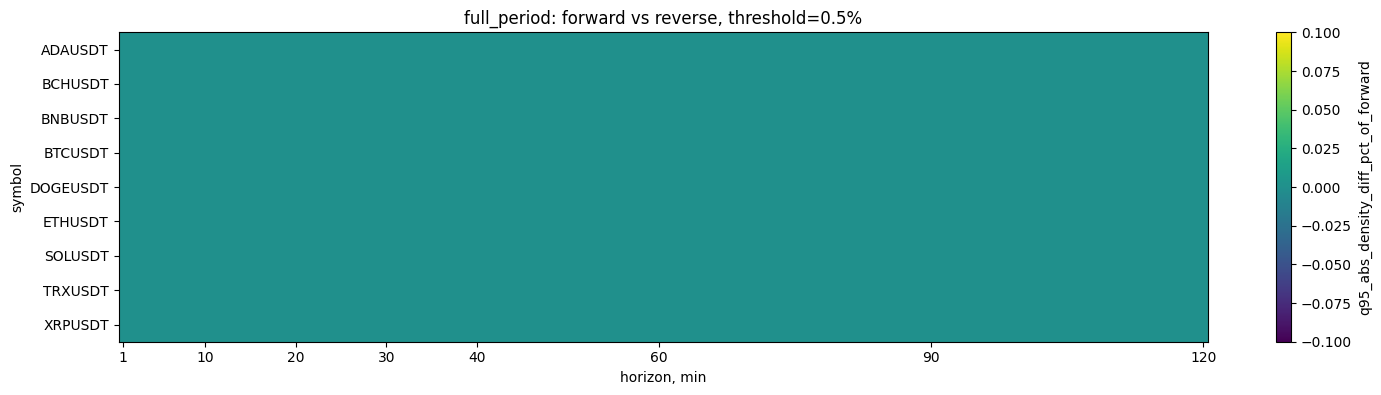

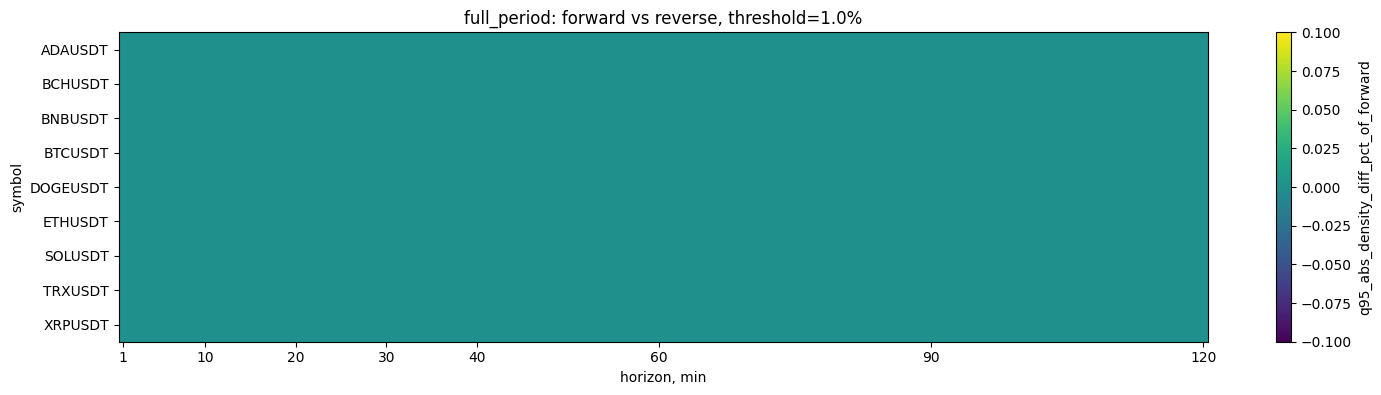

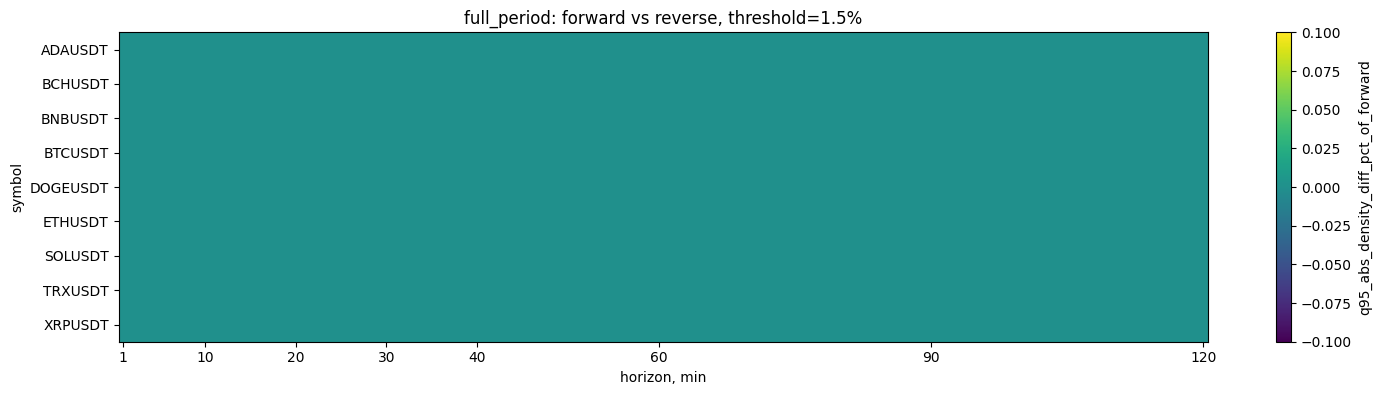

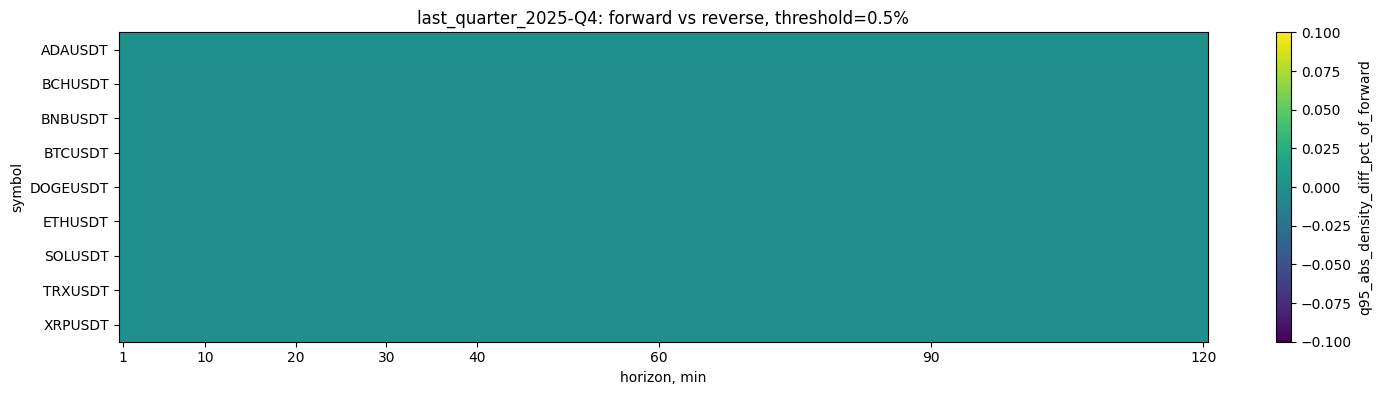

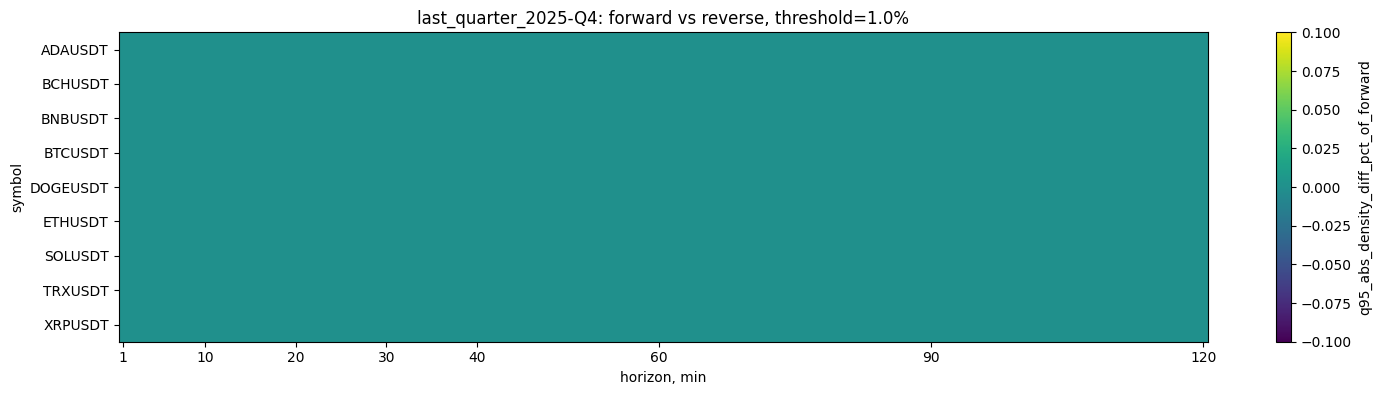

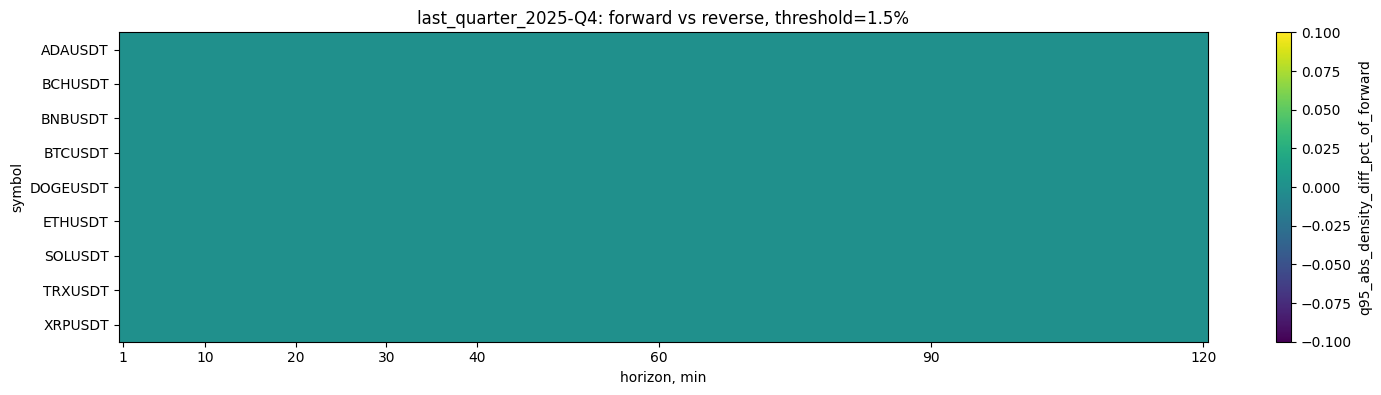

In [13]:
def plot_forward_reverse_density_diff_heatmaps(
    diff_summary: pd.DataFrame,
    scope: str,
    metric: str = "q95_abs_density_diff_pct_of_forward",
    vmax_quantile: float = 0.95,
) -> None:
    data = diff_summary.loc[diff_summary["scope"].eq(scope)].copy()
    thresholds = sorted(data["threshold_pct"].dropna().unique())
    symbols = sorted(data["symbol"].unique())

    for threshold_pct in thresholds:
        part = data.loc[data["threshold_pct"].eq(threshold_pct)]
        grid = part.pivot_table(index="symbol", columns="horizon", values=metric, aggfunc="mean").reindex(symbols)
        vmax = np.nanquantile(grid.to_numpy(dtype=float), vmax_quantile)
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = None

        fig, ax = plt.subplots(figsize=(15, max(3.5, 0.45 * len(symbols))))
        im = ax.imshow(grid.to_numpy(dtype=float), aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
        ax.set_title(f"{scope}: forward vs reverse, threshold={threshold_pct:.1f}%")
        ax.set_xlabel("horizon, min")
        ax.set_ylabel("symbol")
        ax.set_yticks(np.arange(len(symbols)))
        ax.set_yticklabels(symbols)

        x_positions = [h - 1 for h in [1, 10, 20, 30, 40, 60, 90, 120] if h in grid.columns]
        x_labels = [str(h) for h in [1, 10, 20, 30, 40, 60, 90, 120] if h in grid.columns]
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label(metric)
        plt.tight_layout()
        plt.show()


plot_forward_reverse_density_diff_heatmaps(forward_reverse_density_diff_summary, scope="full_period")
plot_forward_reverse_density_diff_heatmaps(forward_reverse_density_diff_summary, scope=f"last_quarter_{last_quarter_label}")

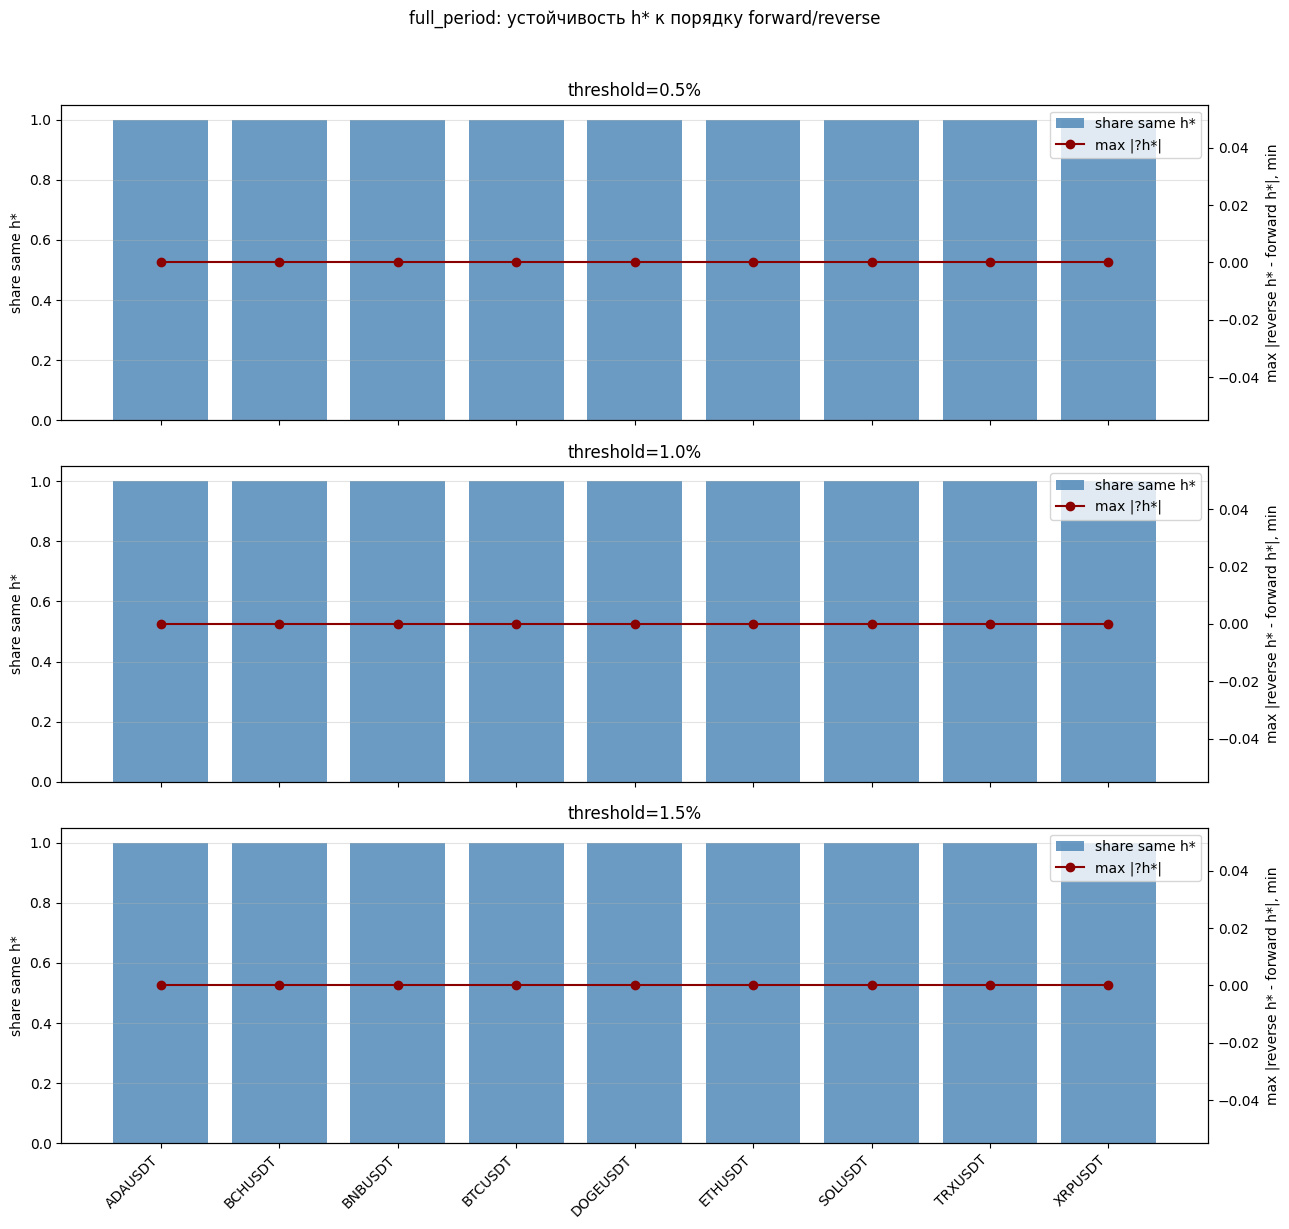

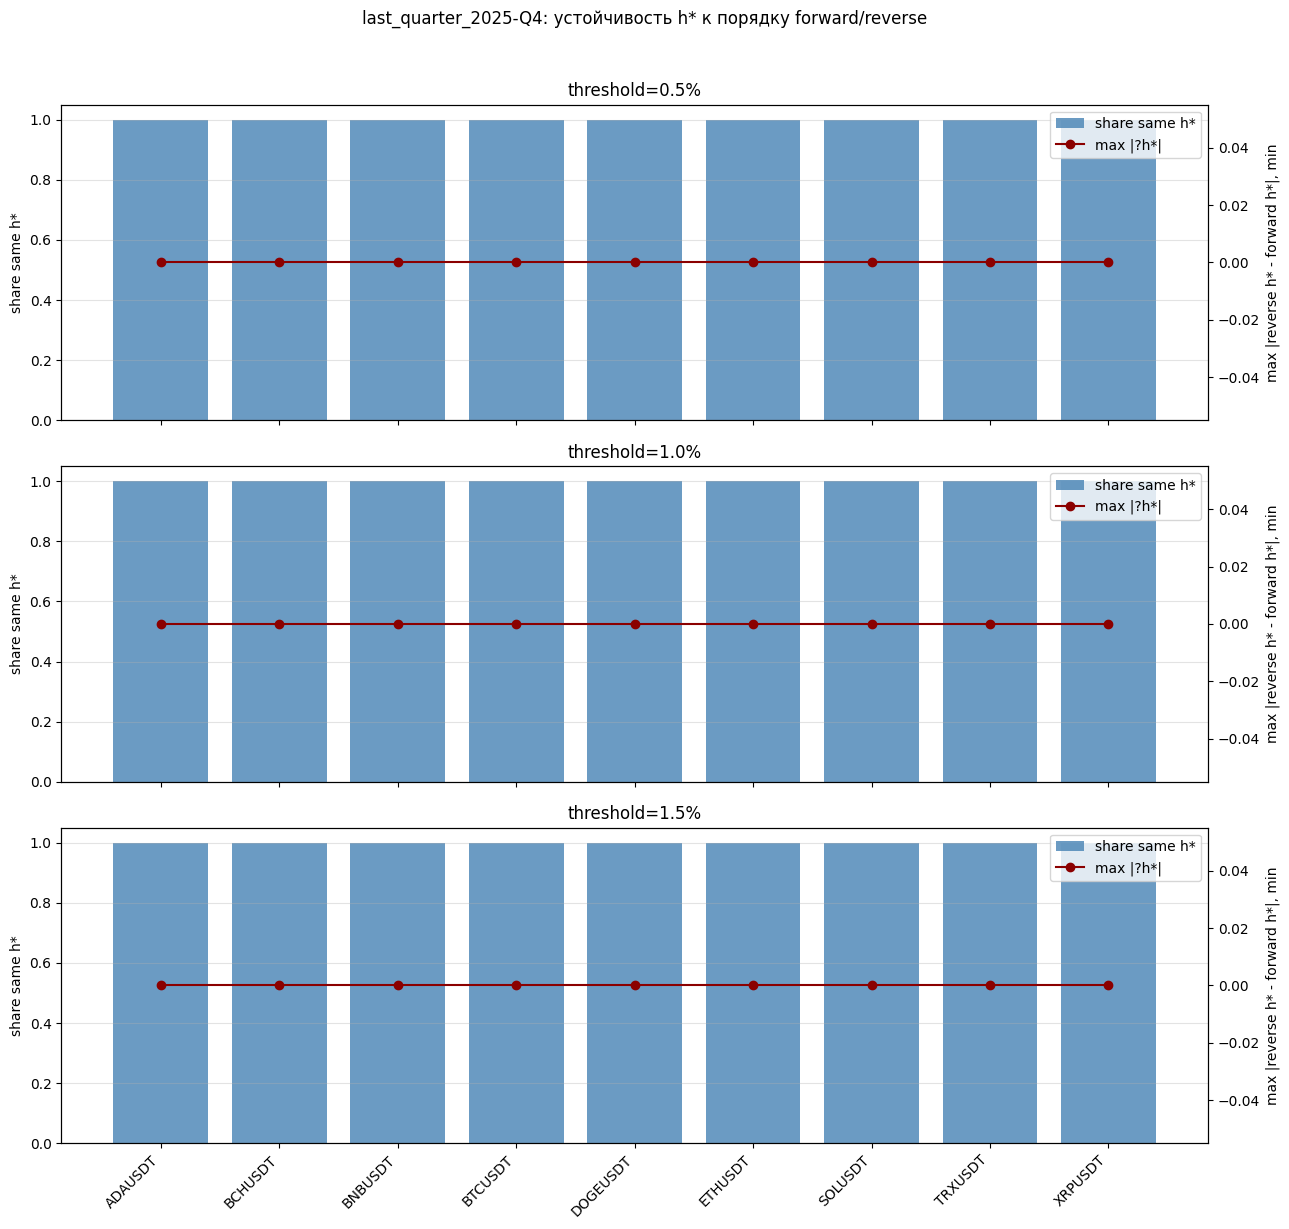

In [14]:
def plot_forward_reverse_best_horizon_summary(best_summary: pd.DataFrame, scope: str) -> None:
    data = best_summary.loc[best_summary["scope"].eq(scope)].copy()
    thresholds = sorted(data["threshold_pct"].dropna().unique())

    fig, axes = plt.subplots(len(thresholds), 1, figsize=(13, 4 * len(thresholds)), sharex=True)
    if len(thresholds) == 1:
        axes = [axes]

    for ax, threshold_pct in zip(axes, thresholds):
        part = data.loc[data["threshold_pct"].eq(threshold_pct)].sort_values("symbol")
        x = np.arange(len(part))
        ax.bar(x, part["share_same_best_horizon"], color="steelblue", alpha=0.8, label="share same h*")
        ax2 = ax.twinx()
        ax2.plot(x, part["max_abs_best_horizon_diff"], color="darkred", marker="o", linewidth=1.5, label="max |?h*|")

        ax.set_title(f"threshold={threshold_pct:.1f}%")
        ax.set_ylabel("share same h*")
        ax.set_ylim(0, 1.05)
        ax2.set_ylabel("max |reverse h* - forward h*|, min")
        ax.set_xticks(x)
        ax.set_xticklabels(part["symbol"], rotation=45, ha="right")
        ax.grid(True, axis="y", alpha=0.35)

        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    fig.suptitle(f"{scope}: устойчивость h* к порядку forward/reverse", y=1.02)
    plt.tight_layout()
    plt.show()


plot_forward_reverse_best_horizon_summary(forward_reverse_best_horizon_summary, scope="full_period")
plot_forward_reverse_best_horizon_summary(forward_reverse_best_horizon_summary, scope=f"last_quarter_{last_quarter_label}")

In [15]:
def display_top_sensitive_horizons(summary: pd.DataFrame, metric: str = "density_range_pct_of_baseline", n: int = 20) -> None:
    cols = [
        "scope", "symbol", "threshold_pct", "horizon", "baseline_density_per_day",
        "mean_density_per_day", "std_density_per_day", "density_range_abs",
        "density_range_pct_of_baseline", "density_iqr90_pct_of_baseline", "event_range",
    ]
    display(
        summary.sort_values(metric, ascending=False)
        .loc[:, cols]
        .head(n)
    )


print("Самые чувствительные горизонты по полному периоду")
display_top_sensitive_horizons(offset_sensitivity_summary.query("scope == 'full_period'"))

print("Самые чувствительные горизонты по последнему кварталу")
display_top_sensitive_horizons(offset_sensitivity_summary.query("scope != 'full_period'"))

Самые чувствительные горизонты по полному периоду


,scope,symbol,threshold_pct,horizon,baseline_density_per_day,mean_density_per_day,std_density_per_day,density_range_abs,density_range_pct_of_baseline,density_iqr90_pct_of_baseline,event_range
2879,full_period,TRXUSDT,1.5,120,2.953283,2.953112,0.000203,0.000459,0.015535,0.015152,1
2876,full_period,TRXUSDT,1.5,117,2.961428,2.961257,0.000203,0.000459,0.015489,0.015106,1
2877,full_period,TRXUSDT,1.5,118,2.964842,2.964671,0.000203,0.000459,0.015472,0.015089,1
2878,full_period,TRXUSDT,1.5,119,2.965959,2.965791,0.000203,0.000459,0.015467,0.015084,1
2875,full_period,TRXUSDT,1.5,116,2.966287,2.966116,0.000203,0.000459,0.015463,0.015080,1
2873,full_period,TRXUSDT,1.5,114,2.984275,2.984104,0.000202,0.000459,0.015367,0.014984,1
2874,full_period,TRXUSDT,1.5,115,2.985852,2.985681,0.000202,0.000459,0.015360,0.014977,1
2872,full_period,TRXUSDT,1.5,113,2.997862,2.997696,0.000202,0.000459,0.015296,0.014913,1
2871,full_period,TRXUSDT,1.5,112,3.015124,3.014954,0.000202,0.000459,0.015208,0.014825,1
2870,full_period,TRXUSDT,1.5,111,3.019059,3.018866,0.000201,0.000458,0.015187,0.014804,1


Самые чувствительные горизонты по последнему кварталу


,scope,symbol,threshold_pct,horizon,baseline_density_per_day,mean_density_per_day,std_density_per_day,density_range_abs,density_range_pct_of_baseline,density_iqr90_pct_of_baseline,event_range
6475,last_quarter_2025-Q4,XRPUSDT,1.5,116,3.992626,3.994077,0.001913,0.010858,0.271964,0.081662,1
6477,last_quarter_2025-Q4,XRPUSDT,1.5,118,3.992687,3.994048,0.002066,0.010859,0.271962,0.081662,1
6474,last_quarter_2025-Q4,XRPUSDT,1.5,115,4.014354,4.015725,0.002067,0.010858,0.270484,0.081660,1
6476,last_quarter_2025-Q4,XRPUSDT,1.5,117,4.014415,4.015786,0.002067,0.010858,0.270484,0.081662,1
6473,last_quarter_2025-Q4,XRPUSDT,1.5,114,4.057840,4.059230,0.002069,0.010858,0.267575,0.081660,1
6472,last_quarter_2025-Q4,XRPUSDT,1.5,113,4.079567,4.081327,0.001347,0.010858,0.266152,0.081664,1
5555,last_quarter_2025-Q4,SOLUSDT,1.0,36,10.078826,10.065143,0.007749,0.026396,0.261892,0.252839,3
5552,last_quarter_2025-Q4,SOLUSDT,1.0,33,10.013364,9.999832,0.007520,0.026209,0.261741,0.252688,3
5559,last_quarter_2025-Q4,SOLUSDT,1.0,40,10.111749,10.096462,0.007315,0.026375,0.260836,0.251784,3
5554,last_quarter_2025-Q4,SOLUSDT,1.0,35,10.089622,10.075944,0.007656,0.026313,0.260790,0.251737,3


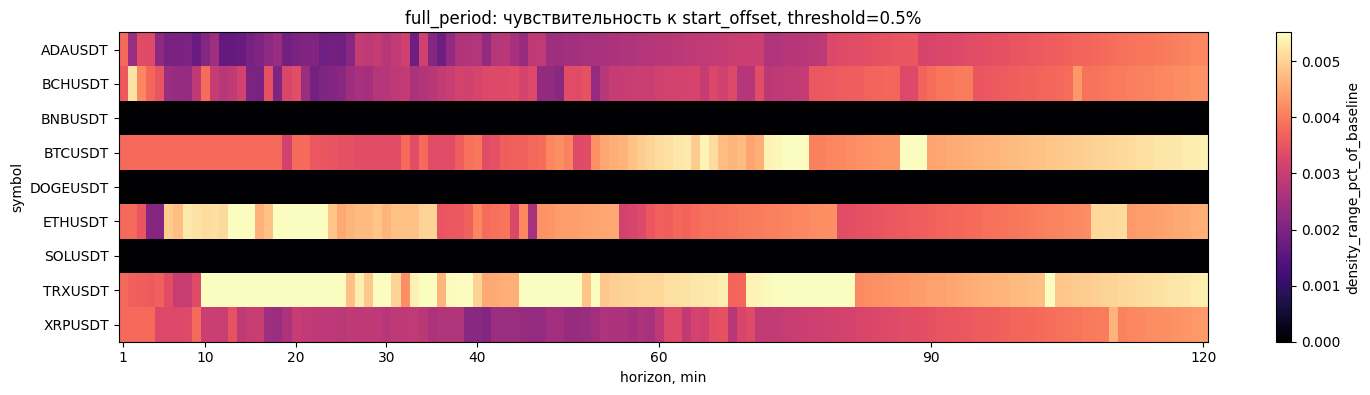

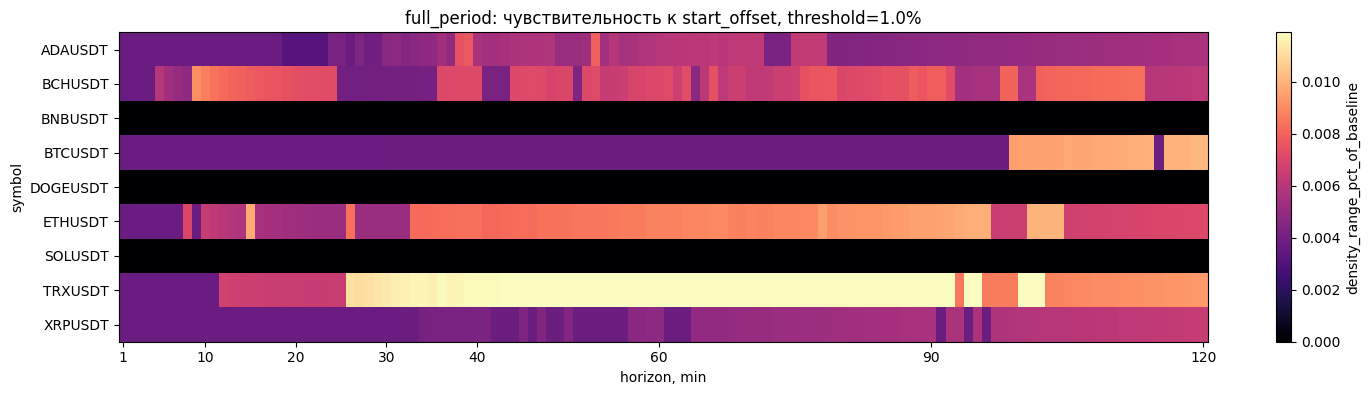

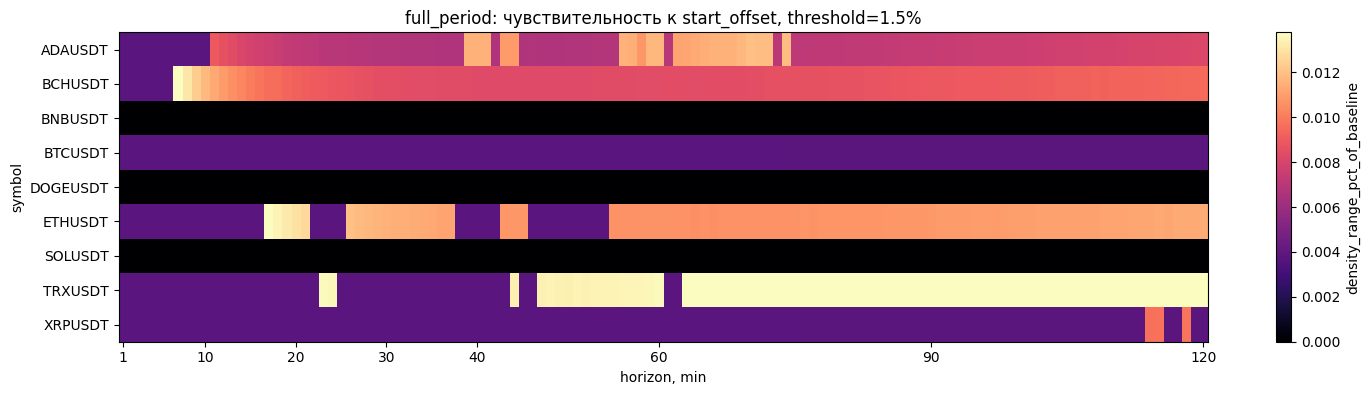

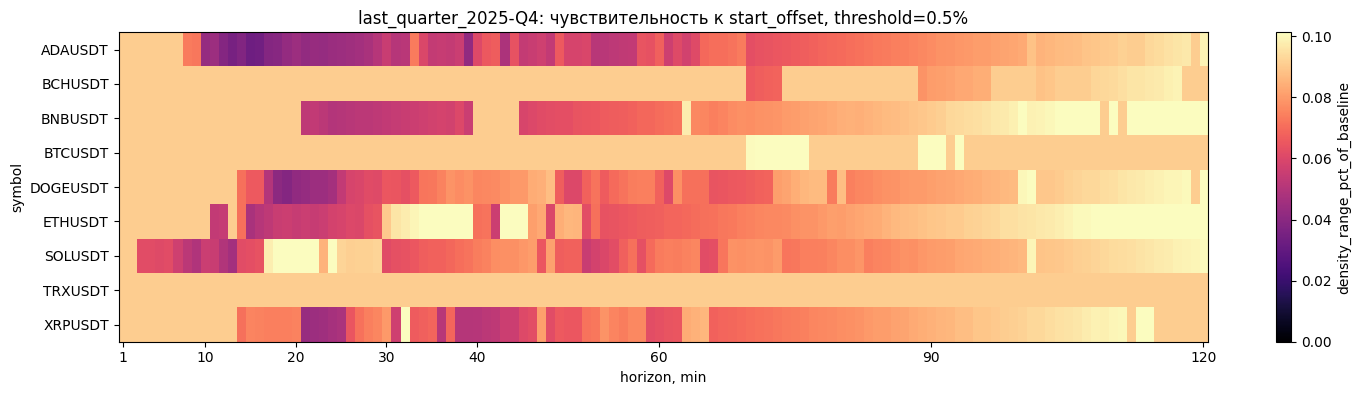

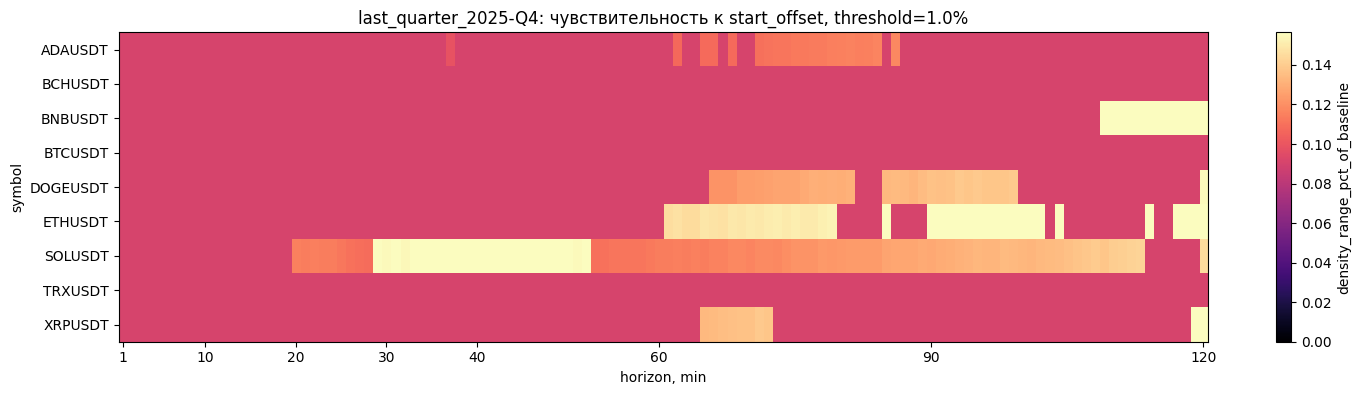

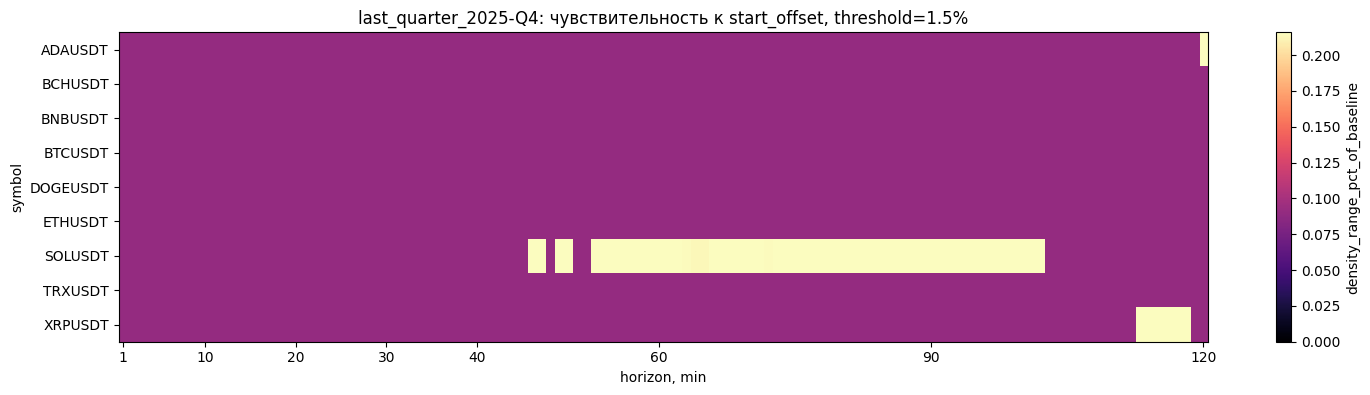

In [16]:
def plot_density_sensitivity_heatmaps(
    summary: pd.DataFrame,
    scope: str,
    metric: str = "density_range_pct_of_baseline",
    vmax_quantile: float = 0.95,
) -> None:
    data = summary.loc[summary["scope"].eq(scope)].copy()
    thresholds = sorted(data["threshold_pct"].dropna().unique())
    symbols = sorted(data["symbol"].unique())

    for threshold_pct in thresholds:
        part = data.loc[data["threshold_pct"].eq(threshold_pct)]
        grid = part.pivot_table(index="symbol", columns="horizon", values=metric, aggfunc="mean").reindex(symbols)
        vmax = np.nanquantile(grid.to_numpy(dtype=float), vmax_quantile)
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = None

        fig, ax = plt.subplots(figsize=(15, max(3.5, 0.45 * len(symbols))))
        im = ax.imshow(grid.to_numpy(dtype=float), aspect="auto", cmap="magma", vmin=0, vmax=vmax)
        ax.set_title(f"{scope}: чувствительность к start_offset, threshold={threshold_pct:.1f}%")
        ax.set_xlabel("horizon, min")
        ax.set_ylabel("symbol")
        ax.set_yticks(np.arange(len(symbols)))
        ax.set_yticklabels(symbols)

        x_positions = [h - 1 for h in [1, 10, 20, 30, 40, 60, 90, 120] if h in grid.columns]
        x_labels = [str(h) for h in [1, 10, 20, 30, 40, 60, 90, 120] if h in grid.columns]
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label(metric)
        plt.tight_layout()
        plt.show()


plot_density_sensitivity_heatmaps(offset_sensitivity_summary, scope="full_period")
plot_density_sensitivity_heatmaps(offset_sensitivity_summary, scope=f"last_quarter_{last_quarter_label}")

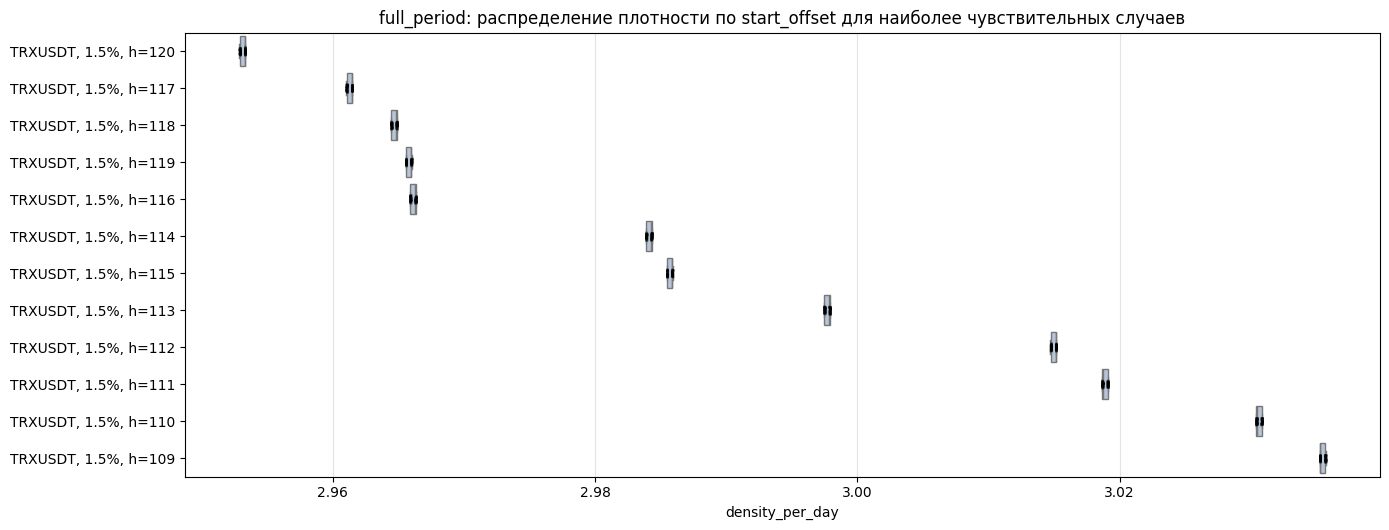

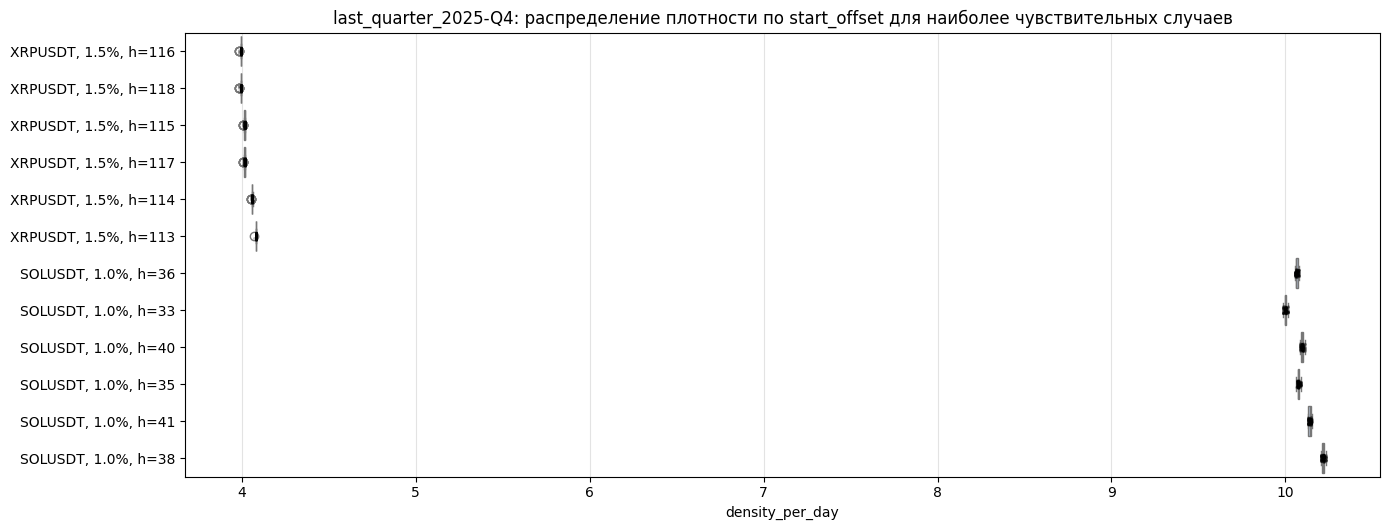

In [17]:
def plot_offset_distribution_for_most_sensitive(
    curves: pd.DataFrame,
    summary: pd.DataFrame,
    scope: str,
    top_n: int = 12,
    metric: str = "density_range_pct_of_baseline",
) -> None:
    top = (
        summary.loc[summary["scope"].eq(scope)]
        .sort_values(metric, ascending=False)
        .head(top_n)
        [["symbol", "threshold_pct", "horizon"]]
    )

    plot_parts = []
    for _, row in top.iterrows():
        part = curves.loc[
            curves["scope"].eq(scope)
            & curves["symbol"].eq(row["symbol"])
            & curves["threshold_pct"].eq(row["threshold_pct"])
            & curves["horizon"].eq(row["horizon"])
        ].copy()
        part["case"] = f'{row["symbol"]}, {row["threshold_pct"]:.1f}%, h={int(row["horizon"])}'
        plot_parts.append(part)

    plot_data = pd.concat(plot_parts, ignore_index=True) if plot_parts else pd.DataFrame()
    if plot_data.empty:
        print("No data to plot")
        return

    fig, ax = plt.subplots(figsize=(14, max(5, 0.45 * plot_data["case"].nunique())))
    if sns is not None:
        sns.boxplot(data=plot_data, y="case", x="density_per_day", ax=ax, color="lightsteelblue")
        sns.stripplot(data=plot_data, y="case", x="density_per_day", ax=ax, color="black", alpha=0.25, size=2)
    else:
        grouped = [g["density_per_day"].to_numpy() for _, g in plot_data.groupby("case", sort=False)]
        labels = [name for name, _ in plot_data.groupby("case", sort=False)]
        ax.boxplot(grouped, vert=False, labels=labels, showfliers=True)

    ax.set_title(f"{scope}: распределение плотности по start_offset для наиболее чувствительных случаев")
    ax.set_xlabel("density_per_day")
    ax.set_ylabel("")
    ax.grid(True, axis="x", alpha=0.35)
    plt.tight_layout()
    plt.show()


plot_offset_distribution_for_most_sensitive(all_offset_density, offset_sensitivity_summary, scope="full_period")
plot_offset_distribution_for_most_sensitive(all_offset_density, offset_sensitivity_summary, scope=f"last_quarter_{last_quarter_label}")

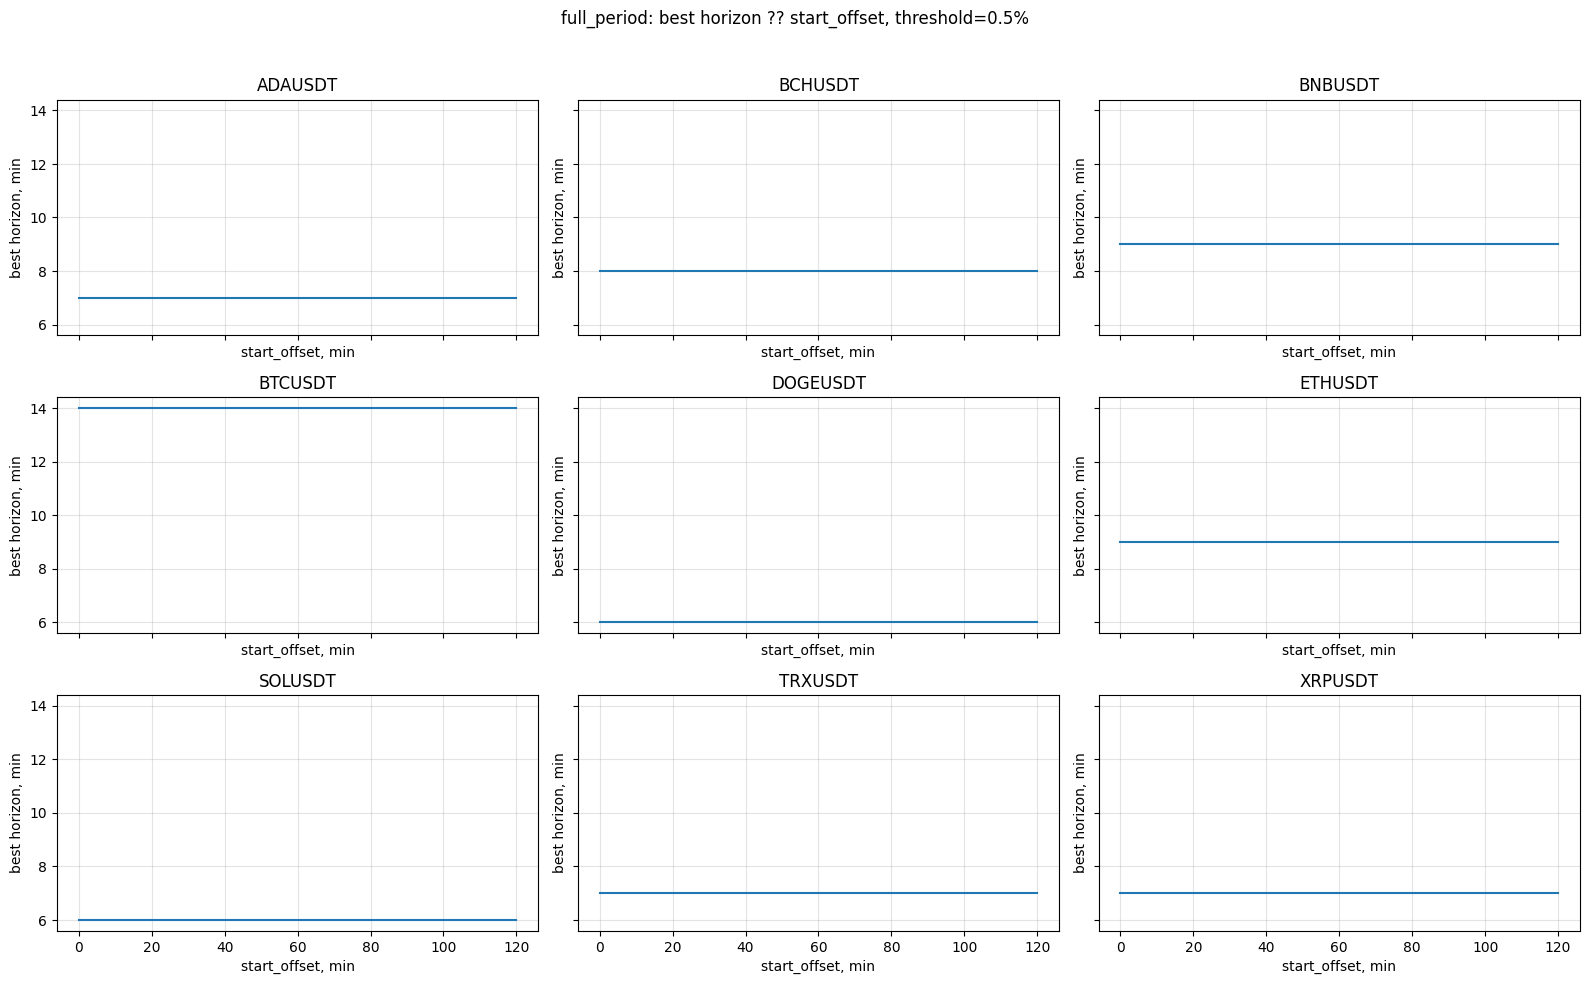

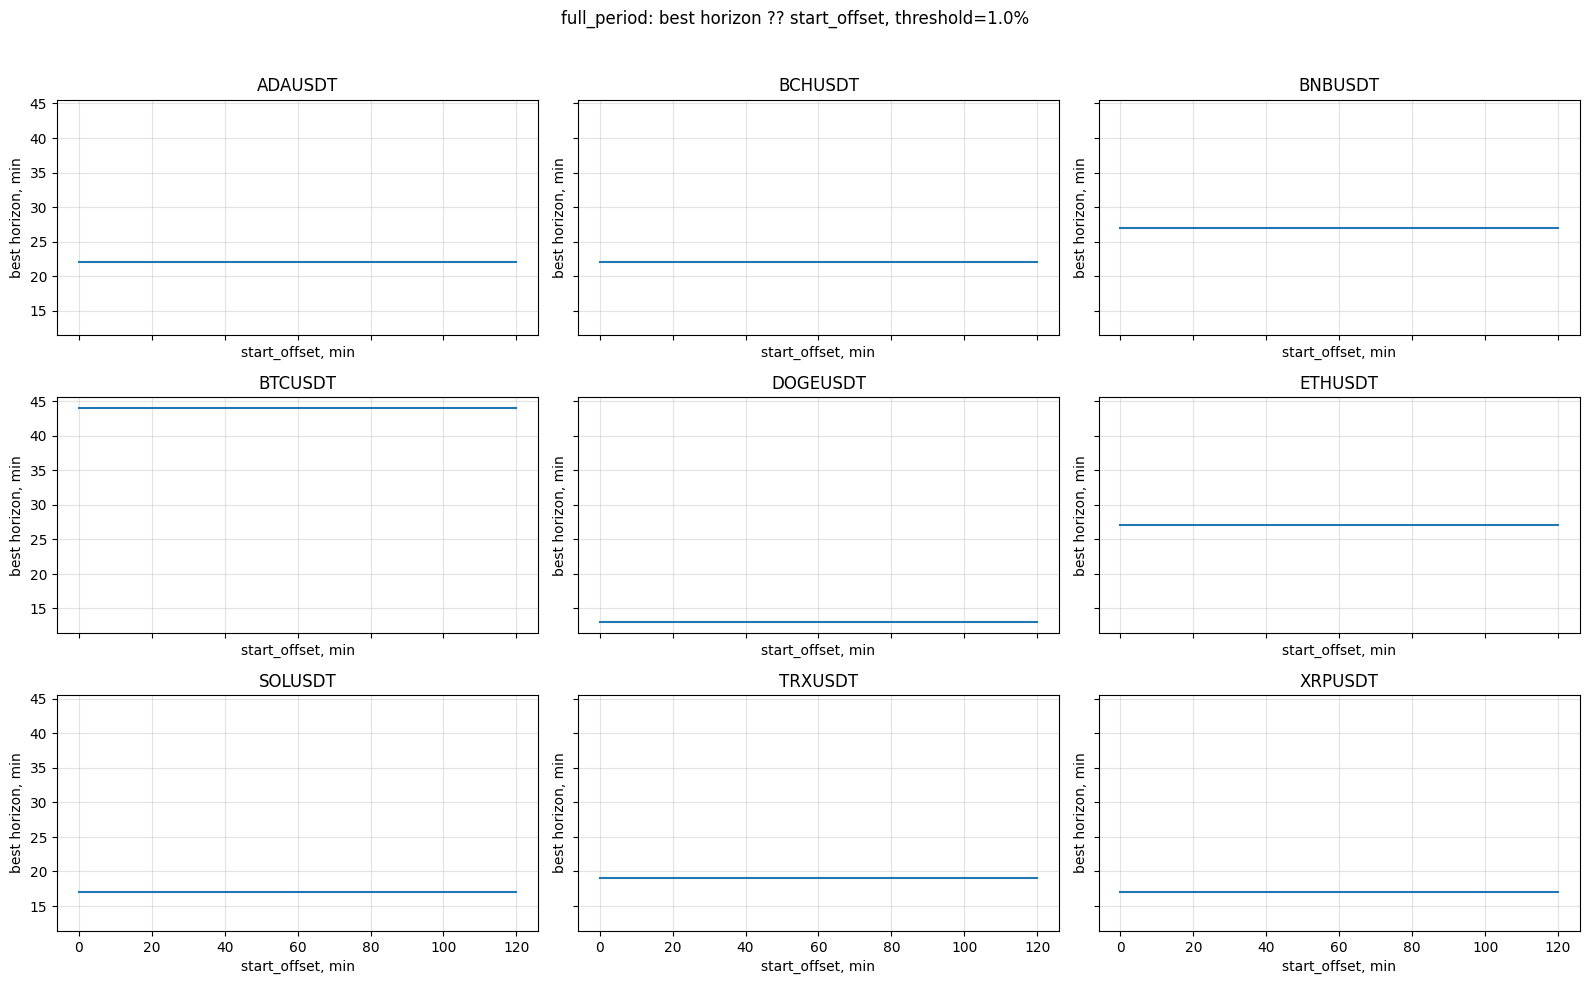

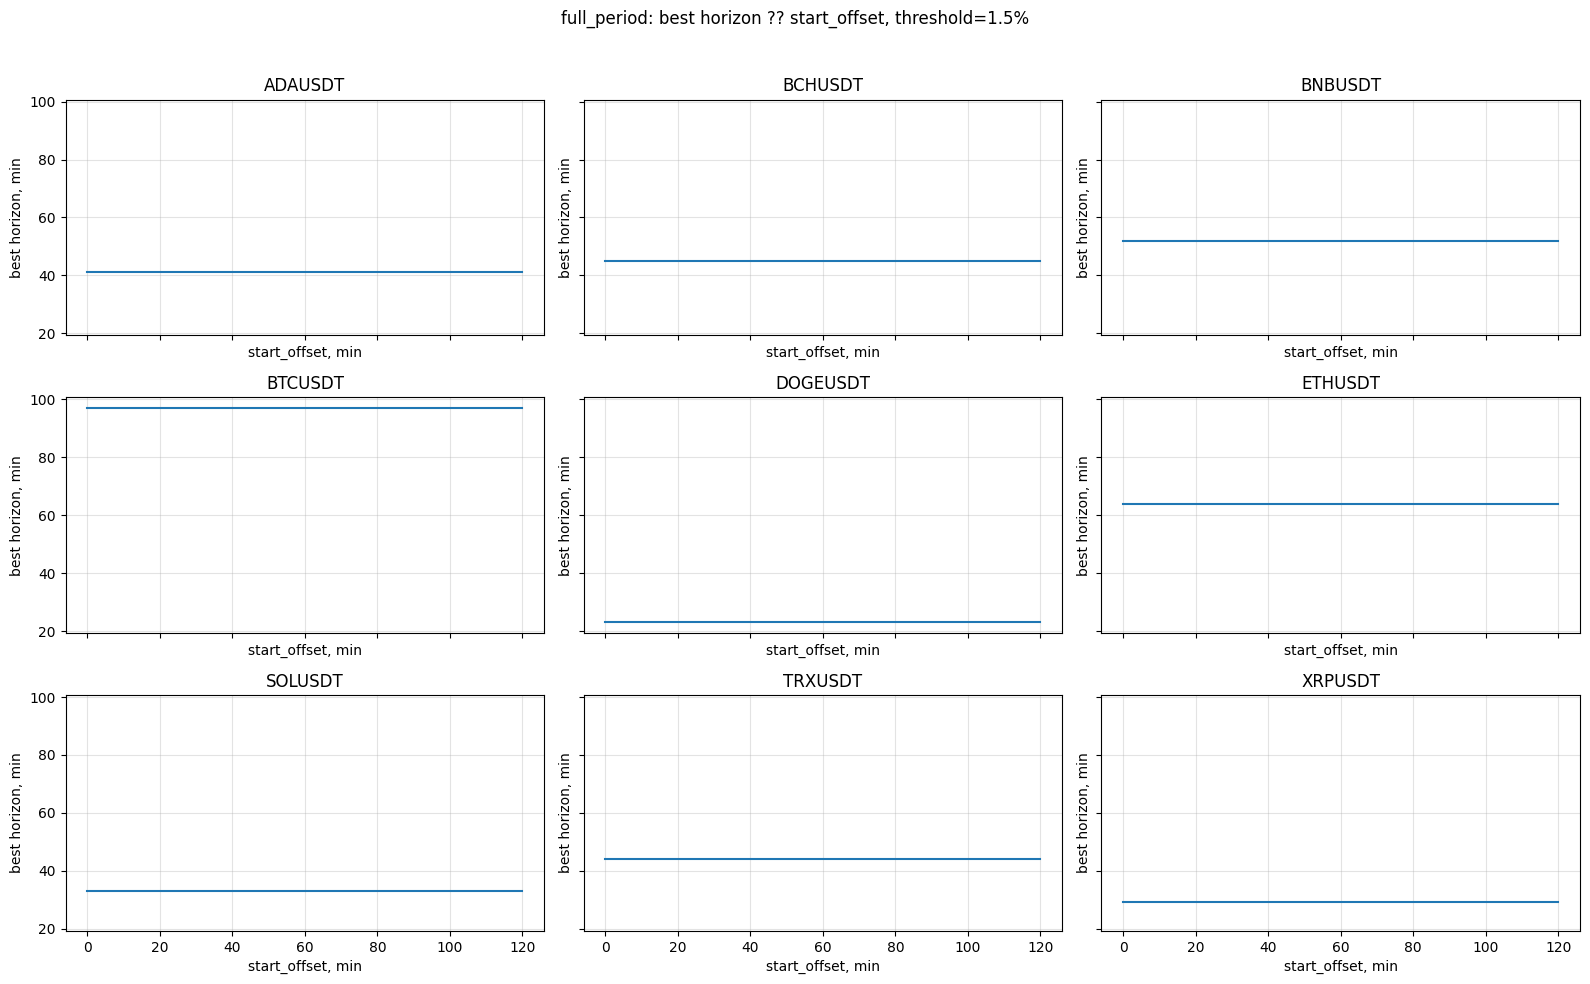

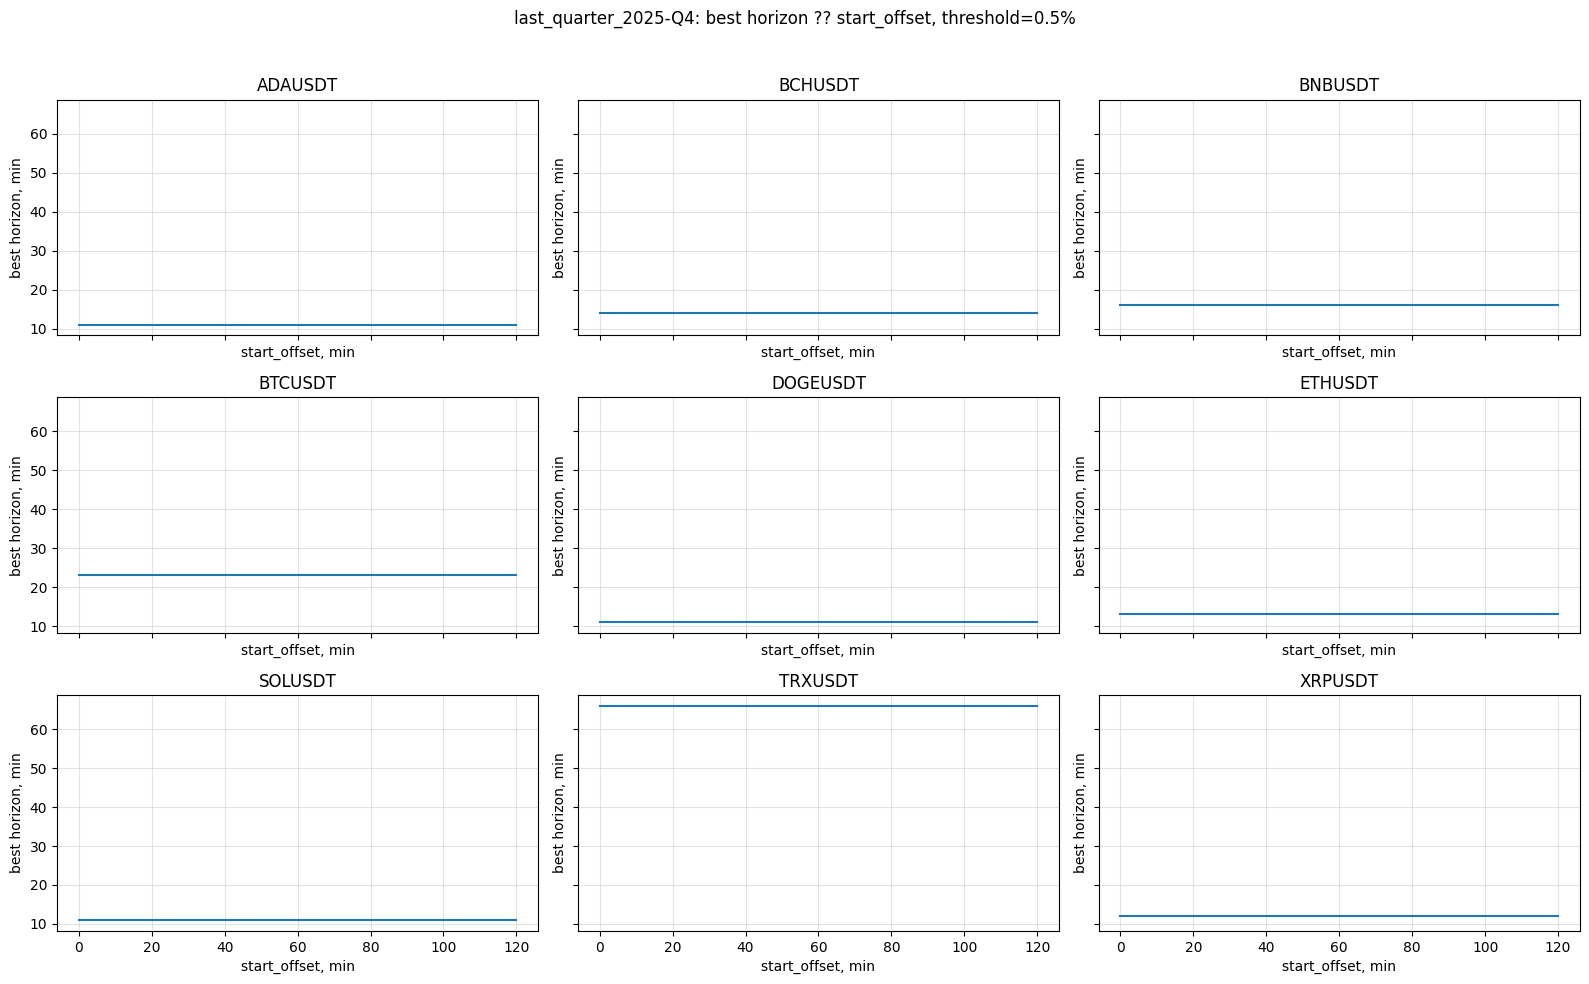

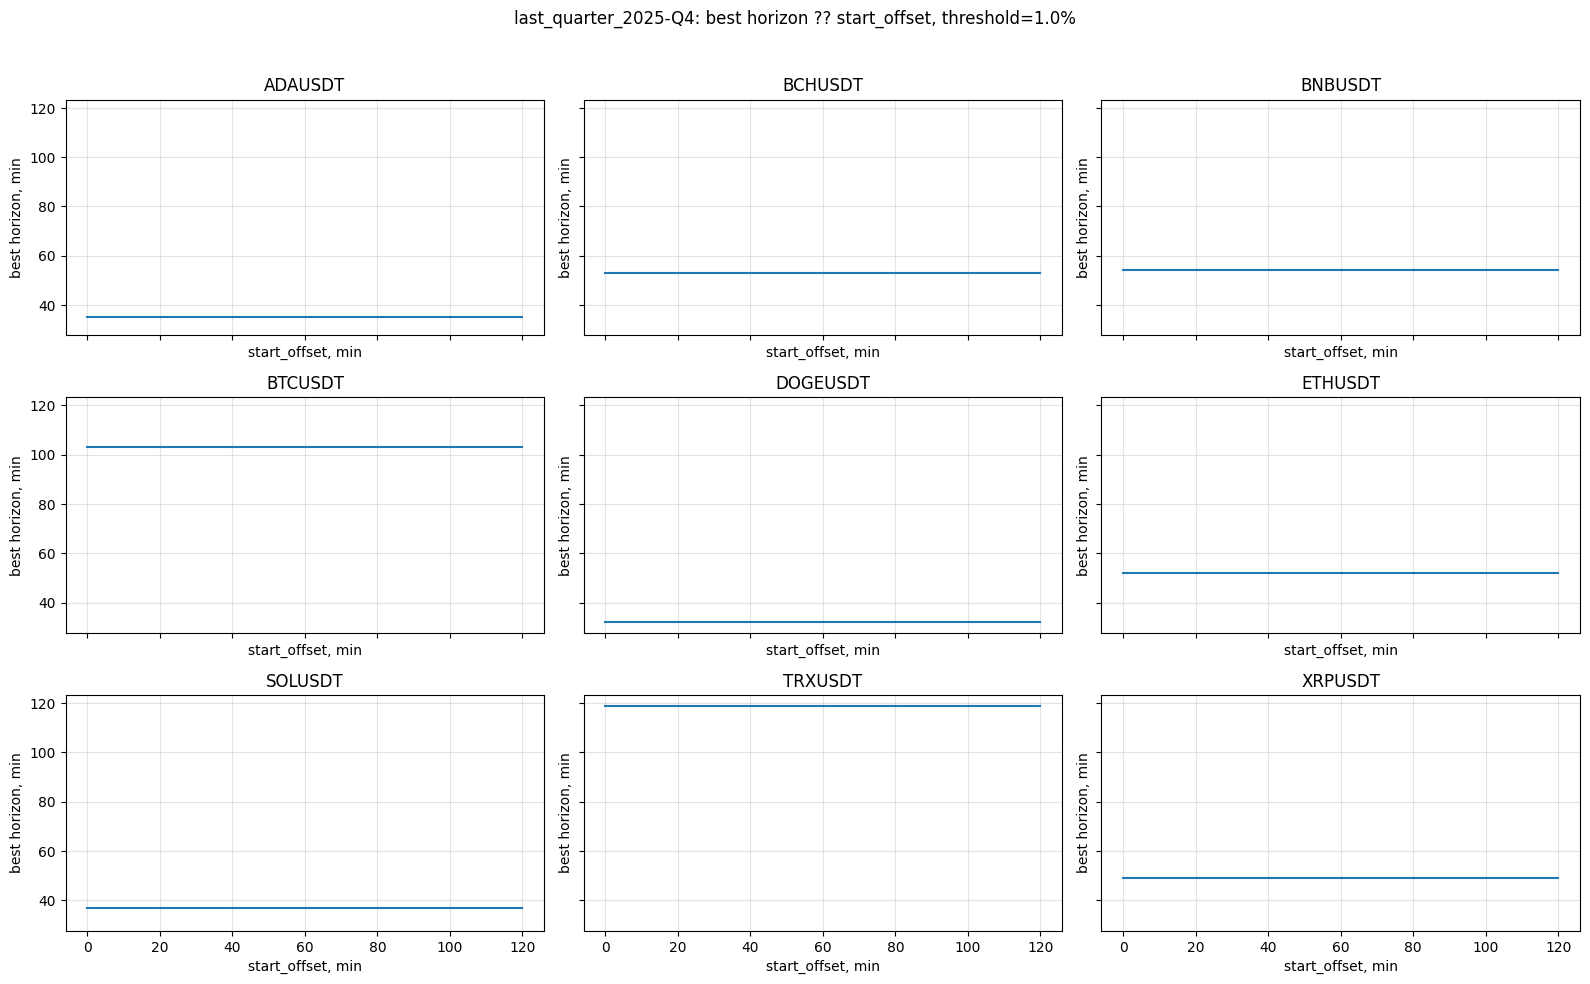

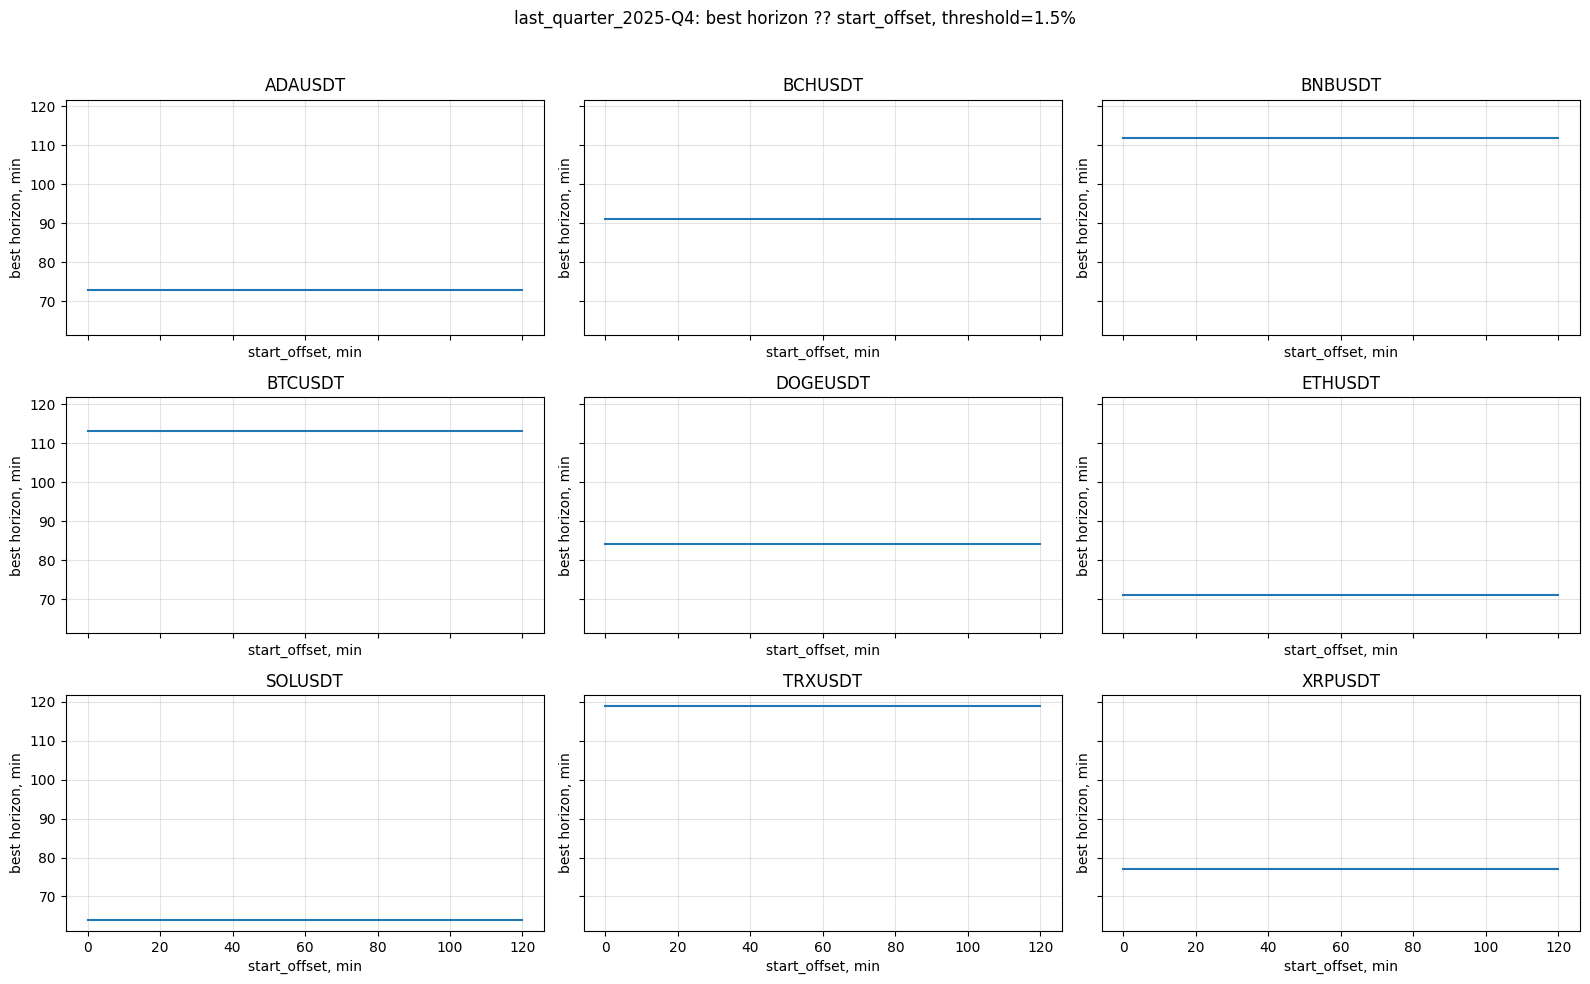

In [18]:
def plot_best_horizon_shift_sensitivity(best_by_offset: pd.DataFrame, scope: str) -> None:
    data = best_by_offset.loc[best_by_offset["scope"].eq(scope)].copy()
    thresholds = sorted(data["threshold_pct"].dropna().unique())
    symbols = sorted(data["symbol"].unique())

    for threshold_pct in thresholds:
        part = data.loc[data["threshold_pct"].eq(threshold_pct)]
        ncols = 3
        nrows = int(np.ceil(len(symbols) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows), sharex=True, sharey=True)
        axes = np.asarray(axes).reshape(-1)

        for ax, symbol in zip(axes, symbols):
            s = part.loc[part["symbol"].eq(symbol)].sort_values("start_offset")
            ax.plot(s["start_offset"], s["best_horizon"], linewidth=1.5)
            ax.set_title(symbol)
            ax.set_xlabel("start_offset, min")
            ax.set_ylabel("best horizon, min")
            ax.grid(True, alpha=0.35)

        for ax in axes[len(symbols):]:
            ax.axis("off")

        fig.suptitle(f"{scope}: best horizon ?? start_offset, threshold={threshold_pct:.1f}%", y=1.02)
        plt.tight_layout()
        plt.show()


plot_best_horizon_shift_sensitivity(best_horizon_by_offset, scope="full_period")
plot_best_horizon_shift_sensitivity(best_horizon_by_offset, scope=f"last_quarter_{last_quarter_label}")

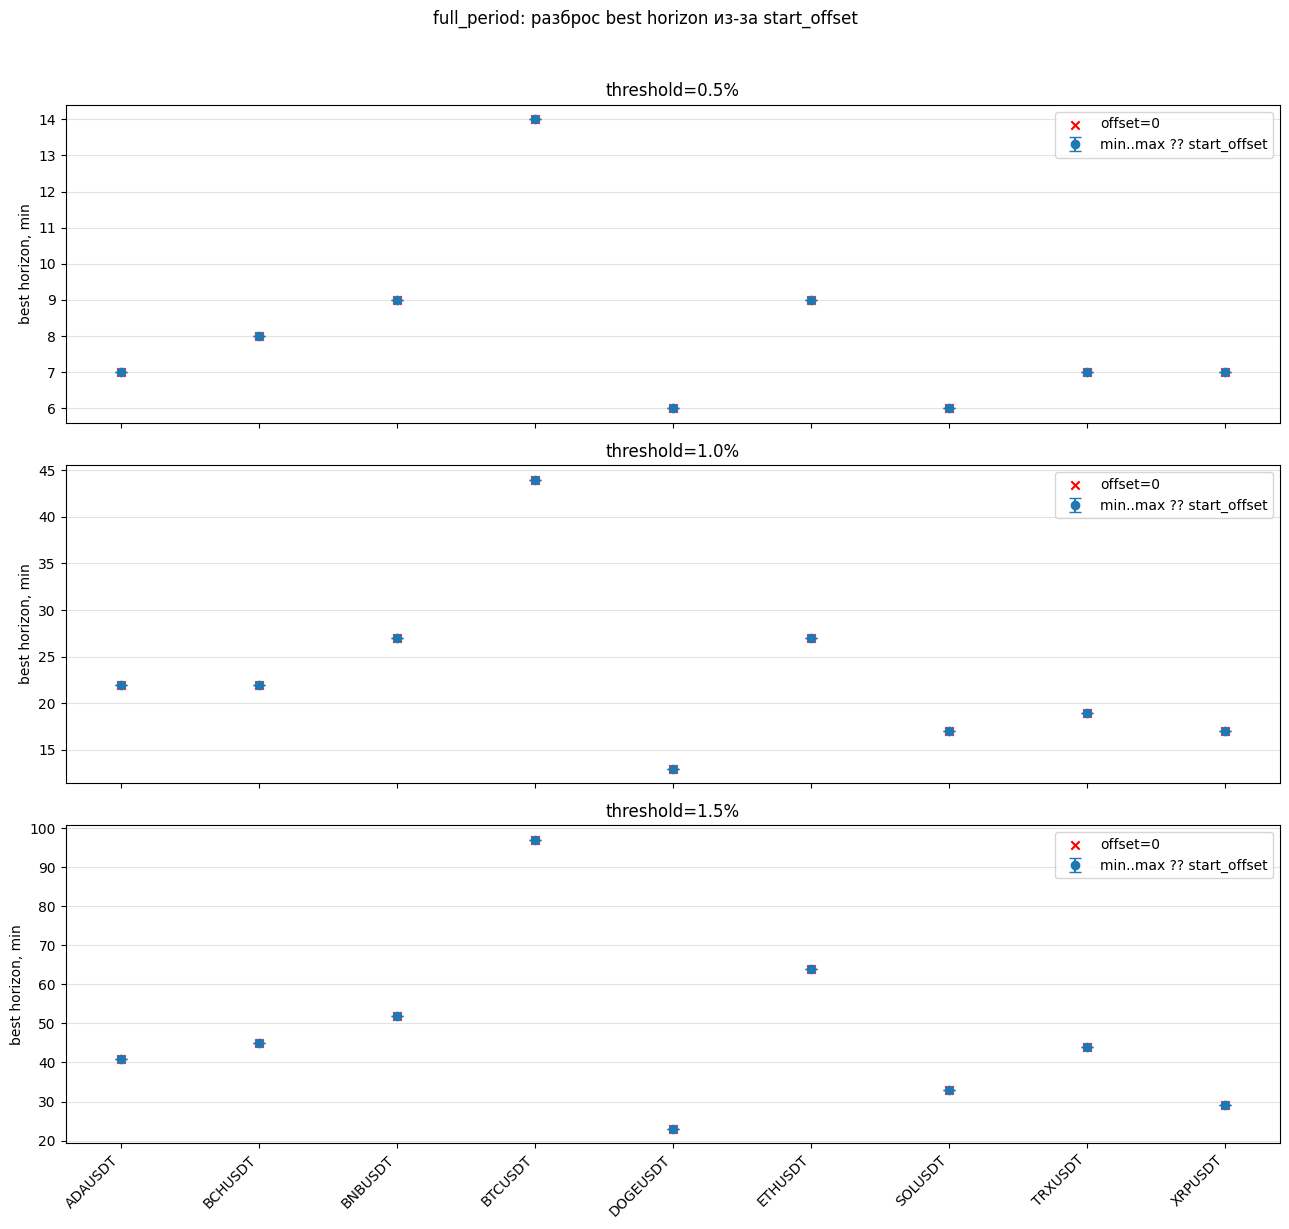

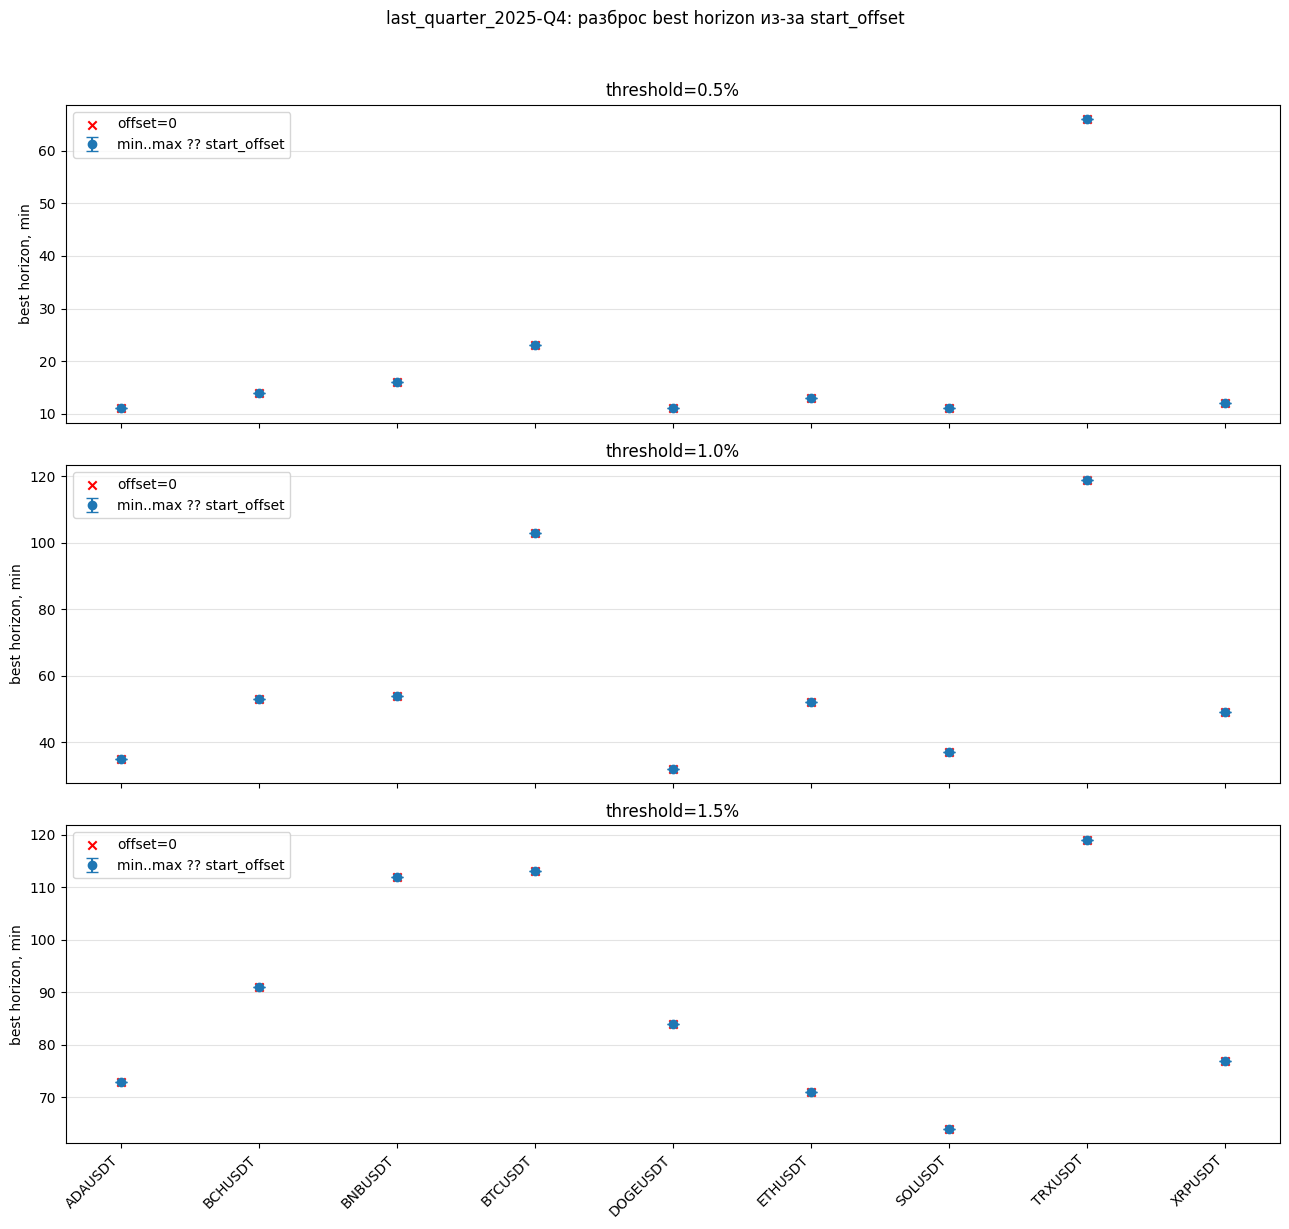

In [19]:
def plot_best_horizon_summary(best_summary: pd.DataFrame, scope: str) -> None:
    data = best_summary.loc[best_summary["scope"].eq(scope)].copy()
    thresholds = sorted(data["threshold_pct"].dropna().unique())

    fig, axes = plt.subplots(len(thresholds), 1, figsize=(13, 4 * len(thresholds)), sharex=True)
    if len(thresholds) == 1:
        axes = [axes]

    for ax, threshold_pct in zip(axes, thresholds):
        part = data.loc[data["threshold_pct"].eq(threshold_pct)].sort_values("symbol")
        x = np.arange(len(part))
        ax.errorbar(
            x,
            part["median_best_horizon"],
            yerr=[
                part["median_best_horizon"] - part["min_best_horizon"],
                part["max_best_horizon"] - part["median_best_horizon"],
            ],
            fmt="o",
            capsize=4,
            label="min..max ?? start_offset",
        )
        ax.scatter(x, part["baseline_best_horizon"], marker="x", color="red", label="offset=0")
        ax.set_title(f"threshold={threshold_pct:.1f}%")
        ax.set_ylabel("best horizon, min")
        ax.set_xticks(x)
        ax.set_xticklabels(part["symbol"], rotation=45, ha="right")
        ax.grid(True, axis="y", alpha=0.35)
        ax.legend()

    fig.suptitle(f"{scope}: разброс best horizon из-за start_offset", y=1.02)
    plt.tight_layout()
    plt.show()


plot_best_horizon_summary(best_horizon_offset_summary, scope="full_period")
plot_best_horizon_summary(best_horizon_offset_summary, scope=f"last_quarter_{last_quarter_label}")

In [20]:
def compare_scopes(summary: pd.DataFrame) -> pd.DataFrame:
    full = summary.loc[summary["scope"].eq("full_period")].copy()
    quarter_scopes = [s for s in summary["scope"].unique() if s != "full_period"]
    if not quarter_scopes:
        return pd.DataFrame()
    quarter_scope = quarter_scopes[0]
    quarter = summary.loc[summary["scope"].eq(quarter_scope)].copy()

    keys = ["symbol", "threshold", "threshold_pct", "horizon"]
    merged = full.merge(
        quarter,
        on=keys,
        how="inner",
        suffixes=("_full", "_last_quarter"),
    )
    merged["range_pct_ratio_last_quarter_to_full"] = (
        merged["density_range_pct_of_baseline_last_quarter"]
        / merged["density_range_pct_of_baseline_full"]
    )
    merged["std_pct_ratio_last_quarter_to_full"] = (
        merged["density_std_pct_of_baseline_last_quarter"]
        / merged["density_std_pct_of_baseline_full"]
    )
    return merged.replace([np.inf, -np.inf], np.nan)


scope_comparison = compare_scopes(offset_sensitivity_summary)
scope_comparison_path = OUTPUT_DIR / "full_vs_last_quarter_offset_sensitivity_comparison.parquet"
scope_comparison.to_parquet(scope_comparison_path, index=False)
print(scope_comparison_path)

display(
    scope_comparison.sort_values("range_pct_ratio_last_quarter_to_full", ascending=False)
    .loc[:, [
        "symbol", "threshold_pct", "horizon",
        "density_range_pct_of_baseline_full",
        "density_range_pct_of_baseline_last_quarter",
        "range_pct_ratio_last_quarter_to_full",
        "density_std_pct_of_baseline_full",
        "density_std_pct_of_baseline_last_quarter",
    ]]
    .head(30)
)

cache\start_offset_sensitivity\full_vs_last_quarter_offset_sensitivity_comparison.parquet


,symbol,threshold_pct,horizon,density_range_pct_of_baseline_full,density_range_pct_of_baseline_last_quarter,range_pct_ratio_last_quarter_to_full,density_std_pct_of_baseline_full,density_std_pct_of_baseline_last_quarter
3235,XRPUSDT,1.5,116,0.003833,0.271964,70.960728,0.001120,0.047919
3236,XRPUSDT,1.5,117,0.003833,0.270484,70.569442,0.001120,0.051485
3232,XRPUSDT,1.5,113,0.003832,0.266152,69.459231,0.001120,0.033019
381,BCHUSDT,0.5,22,0.001881,0.090677,48.213315,0.000486,0.026503
6,ADAUSDT,0.5,7,0.001946,0.090667,46.595183,0.000476,0.026500
5,ADAUSDT,0.5,6,0.001979,0.090666,45.818797,0.000494,0.026500
375,BCHUSDT,0.5,16,0.001980,0.090673,45.801369,0.000464,0.026502
374,BCHUSDT,0.5,15,0.001993,0.090672,45.499660,0.000465,0.026502
382,BCHUSDT,0.5,23,0.002009,0.090678,45.135972,0.000508,0.026503
377,BCHUSDT,0.5,18,0.002017,0.090674,44.955847,0.000460,0.026502


## Что смотреть в первую очередь

- `density_range_pct_of_baseline`: максимальный разброс плотности по стартовым сдвигам относительно базовой плотности при `start_offset=0`.
- `density_iqr90_pct_of_baseline`: устойчивый 90%-диапазон плотностей по сдвигам относительно базовой плотности.
- `best_horizon_range` и `unique_best_horizons`: насколько сильно выбор стартовой точки меняет выбранный оптимальный горизонт.
- `forward_reverse_density_diff_summary`: насколько меняется плотность при альтернативном порядке обработки `forward`/`reverse`.
- `forward_reverse_best_horizon_summary`: насколько меняется оптимальный горизонт при альтернативном порядке обработки.
- Сравнение `full_period` и последнего полного квартала показывает, усиливается ли чувствительность на коротком недавнем окне.